# 1. Purpose of this notebook

Notebook 01 trained and evaluated the original baseline model using the complete permanent training split. A deletion request identifies records that must be removed, but deleting rows from a CSV does not remove their influence from an already-trained model. Full retraining instead creates fresh model parameters and a fresh preprocessor using retained training data only. It is the reference method because affected training records are never used for preprocessing or parameter updates. Later approximate-unlearning methods will be compared with these references.

> After different data-deletion requests, what predictive utility is achieved by retraining the model from scratch using only retained training data?

The supporting question is: *How do the size and structure of the deletion request relate to retained utility, training time and model behaviour on the deleted training records?* The notebook examines utility after deletion, small and large requests, complete- and partial-history removal, two differently structured 10% scenarios, and the reference behaviour later approximate methods should try to reproduce.

This notebook defines five deletion scenarios, creates their training forget and retained sets, and trains five fresh models. Deleted training rows are excluded from preprocessing, parameter updates and early stopping. The Notebook 01 architecture remains fixed. Full retraining is a reference rather than approximate unlearning, and results from generated data do not establish clinical effectiveness.

# 2. Setup and reproducibility

This section fixes the paths, seed and deterministic CPU settings shared with Notebook 01. Each scenario resets seed 42 immediately before constructing its fresh model.

In [1]:
# Import only the libraries required by the established notebook workflow.
import copy
import json
import platform
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer


In [2]:
# Import only the libraries required by the established notebook workflow.
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

All paths resolve from `final_submission`. Inputs include both authoritative tables, their contracts, permanent splits and the frozen baseline. New outputs use one membership CSV, flat scenario-prefixed model files and combined result tables.

In [3]:
def locate_submission_root() -> Path:
    # Support execution from the repository root or notebook directory.
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents, cwd / "final_submission"]:
        direct = candidate / "data/final/kidney_transplant_assessments.csv"
        nested = candidate / "final_submission/data/final/kidney_transplant_assessments.csv"
        if direct.is_file():
            return candidate
        if nested.is_file():
            return candidate / "final_submission"
    raise FileNotFoundError("Could not locate final_submission/data/final")


ROOT = locate_submission_root()
DATA_DIR = ROOT / "data/final"
PROCESSED_DIR = ROOT / "processed_data"
BASELINE_MODEL_DIR = ROOT / "models/baseline"
BASELINE_RESULT_DIR = ROOT / "results/baseline"


In [4]:
# Save reproducibility artefacts only after the corresponding checks have passed.
MODEL_DIR = ROOT / "models/full_retraining"
RESULT_DIR = ROOT / "results/full_retraining"
FIGURE_DIR = RESULT_DIR / "figures"
for directory in (MODEL_DIR, RESULT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "deletion scenarios and full retraining"}, indent=2) + "\n",
    encoding="utf-8",
)

78

In [5]:
# Reuse the frozen dataset, split and baseline paths from Notebook 01.
ASSESSMENT_PATH = DATA_DIR / "kidney_transplant_assessments.csv"
IDENTITY_PATH = DATA_DIR / "kidney_transplant_identity.csv"
DICTIONARY_PATH = DATA_DIR / "data_dictionary.csv"
FEATURE_PATH = DATA_DIR / "classifier_feature_list.json"
DELETION_AUDIT_PATH = DATA_DIR / "deletion_scenario_audit.csv"
SPLIT_PATH = PROCESSED_DIR / "split_assignments.csv"
BASELINE_MODEL_PATH = BASELINE_MODEL_DIR / "baseline_model.pt"
BASELINE_PREPROCESSOR_PATH = BASELINE_MODEL_DIR / "baseline_preprocessor.joblib"
BASELINE_CONFIG_PATH = BASELINE_MODEL_DIR / "model_configuration.json"
BASELINE_METRICS_PATH = BASELINE_RESULT_DIR / "test_metrics.csv"
BASELINE_PREDICTIONS_PATH = BASELINE_RESULT_DIR / "test_predictions.csv"
MEMBERSHIP_PATH = PROCESSED_DIR / "deletion_scenario_membership.csv"


In [6]:
# Keep this stage separate so its inputs and checks remain easy to audit.

display(pd.Series({
    "assessment table": ASSESSMENT_PATH.relative_to(ROOT).as_posix(),
    "identity table": IDENTITY_PATH.relative_to(ROOT).as_posix(),
    "permanent splits": SPLIT_PATH.relative_to(ROOT).as_posix(),
    "baseline model": BASELINE_MODEL_PATH.relative_to(ROOT).as_posix(),
    "new model directory": MODEL_DIR.relative_to(ROOT).as_posix(),
    "new result directory": RESULT_DIR.relative_to(ROOT).as_posix(),
}).to_frame("path"))

,path
assessment table,data/final/kidney_transplant_assessments.csv
identity table,data/final/kidney_transplant_identity.csv
permanent splits,processed_data/split_assignments.csv
baseline model,models/baseline/baseline_model.pt
new model directory,models/full_retraining
new result directory,results/full_retraining


Seed 42 controls Python, NumPy and PyTorch. CPU and deterministic PyTorch operations match Notebook 01. The reset function is called immediately before every scenario model is constructed, so all five begin from the same reproducible parameter initialisation.

In [7]:
# Reset this seed before each fresh scenario model for a fair comparison.
SEED = 42
DEVICE = torch.device("cpu")


def reset_seed() -> None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)


reset_seed()
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

# 3. Load the dataset and frozen baseline artefacts

The assessment table supplies modelling and pseudonymous audit fields. The identity table is used only to verify recipient/donor entity relationships; names, email addresses and other direct identity fields are neither displayed nor saved in predictions.

In [8]:
# Keep identity data separate from classifier inputs and saved predictions.
assessments = pd.read_csv(ASSESSMENT_PATH)
identity = pd.read_csv(IDENTITY_PATH)

assert assessments.shape == (60_000, 31)
assert assessments["recipient_id"].nunique() == 10_000
assert assessments["donor_id"].nunique() == 8_000
assert identity.shape[0] == 18_000

recipient_entities = set(identity.loc[identity["person_role"].eq("Recipient"), "entity_id"])
donor_entities = set(identity.loc[identity["person_role"].eq("Donor"), "entity_id"])
assert recipient_entities == set(assessments["recipient_id"])
assert donor_entities == set(assessments["donor_id"])


In [9]:
# Keep this stage separate so its inputs and checks remain easy to audit.

display(pd.Series({
    "assessments": len(assessments),
    "recipients": assessments["recipient_id"].nunique(),
    "unique donors": assessments["donor_id"].nunique(),
    "identity rows": len(identity),
    "identity relationship check": "PASS",
}).to_frame("value"))

,value
assessments,60000
recipients,10000
unique donors,8000
identity rows,18000
identity relationship check,PASS


The feature contract is loaded rather than repeated manually. The same 15 numerical/binary and three categorical raw inputs are used throughout.

In [10]:
# Keep the feature contract and ordering fixed across all scenarios.
feature_contract = json.loads(FEATURE_PATH.read_text(encoding="utf-8"))
data_dictionary = pd.read_csv(DICTIONARY_PATH)
classifier_features = feature_contract["classifier_features"]
target_column = feature_contract["target"]
categorical_features = ["donor_type", "kidney_failure_cause", "abo_compatibility_category"]
numeric_features = [feature for feature in classifier_features if feature not in categorical_features]

assert len(classifier_features) == 18
assert len(numeric_features) == 15
assert len(categorical_features) == 3
assert target_column == "acute_rejection_within_30_days"


In [11]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(pd.Series({
    "raw classifier features": len(classifier_features),
    "numerical or binary": len(numeric_features),
    "categorical": len(categorical_features),
    "target": target_column,
}).to_frame("value"))

,value
raw classifier features,18
numerical or binary,15
categorical,3
target,acute_rejection_within_30_days


Notebook 02 reads the exact seed-42 split assignments and reconciles them with the three permanent assessment files. It does not create a new random split.

In [12]:
# Load the permanent split rather than creating new membership.
split_assignments = pd.read_csv(SPLIT_PATH)
split_by_recipient = split_assignments.set_index("recipient_id")["split"]
assessment_split = assessments["recipient_id"].map(split_by_recipient)
assert assessment_split.notna().all()

split_frames = {
    name: assessments.loc[assessment_split.eq(name)].copy()
    for name in ["train", "validation", "test"]
}
expected_split_files = {
    "train": PROCESSED_DIR / "training_assessments.csv",
    "validation": PROCESSED_DIR / "validation_assessments.csv",
    "test": PROCESSED_DIR / "test_assessments.csv",
}


In [13]:
# Load frozen inputs so this stage reuses rather than regenerates earlier evidence.
for name, file_path in expected_split_files.items():
    saved = pd.read_csv(file_path)
    assert set(saved["assessment_id"]) == set(split_frames[name]["assessment_id"])

split_dimensions = pd.DataFrame([
    {"split": name, "assessments": len(frame), "recipients": frame["recipient_id"].nunique()}
    for name, frame in split_frames.items()
]).set_index("split")
assert split_dimensions["assessments"].to_dict() == {"train": 42_024, "validation": 8_988, "test": 8_988}
assert split_dimensions["recipients"].to_dict() == {"train": 7_004, "validation": 1_498, "test": 1_498}
display(split_dimensions)

,assessments,recipients
split,,
train,42024,7004
validation,8988,1498
test,8988,1498


The baseline checkpoint, fitted preprocessor, configuration, threshold, metrics and saved test predictions are loaded read-only. The architecture class is reproduced exactly so the checkpoint can be inspected and later evaluated on scenario-retained rows.

In [14]:
class BaselineMLP(nn.Module):
    # Fixed small binary MLP shared by the baseline and full retraining.
    def __init__(self, input_dim: int, hidden_dims=(64, 32), dropout: float = 0.10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs).squeeze(1)


In [15]:
# Load frozen inputs so this stage reuses rather than regenerates earlier evidence.


def load_checkpoint(file_path: Path) -> dict:
    try:
        return torch.load(file_path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(file_path, map_location=DEVICE)

In [16]:
# Load the baseline for comparison only, never as retraining initialisation.
baseline_config = json.loads(BASELINE_CONFIG_PATH.read_text(encoding="utf-8"))
baseline_checkpoint = load_checkpoint(BASELINE_MODEL_PATH)
baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)
baseline_saved_predictions = pd.read_csv(BASELINE_PREDICTIONS_PATH)

baseline_model = BaselineMLP(
    baseline_checkpoint["input_dim"],
    tuple(baseline_checkpoint["hidden_dims"]),
    baseline_checkpoint["dropout"],
).to(DEVICE)
baseline_model.load_state_dict(baseline_checkpoint["model_state_dict"])
baseline_model.eval()

FROZEN_THRESHOLD = float(baseline_config["threshold"])
assert FROZEN_THRESHOLD == 0.62


In [17]:
# Visualise established results without using the figure to tune the experiment.
display(pd.Series({
    "baseline processed inputs": baseline_config["input_dim_processed"],
    "baseline parameters": baseline_config["parameter_count"],
    "frozen threshold": FROZEN_THRESHOLD,
    "baseline checkpoint loaded": True,
    "baseline preprocessor loaded": True,
}).to_frame("value"))

,value
baseline processed inputs,24
baseline parameters,3713
frozen threshold,0.62
baseline checkpoint loaded,True
baseline preprocessor loaded,True


This table checks structural and feature compatibility without adding hash verification to the notebook narrative.

In [18]:
# Confirm direct identity fields cannot enter the model matrix.
identity_direct_fields = {
    "full_name", "date_of_birth", "email_address", "postcode", "hospital_number"
}
all_split_ids = pd.concat([
    frame[["assessment_id"]].assign(split=name)
    for name, frame in split_frames.items()
], ignore_index=True)


In [19]:
# Fail early if this stage no longer matches the frozen experiment contract.
input_checks = pd.DataFrame([
    {"check": "Assessment IDs unique", "pass": assessments["assessment_id"].is_unique},
    {"check": "Splits cover every assessment once", "pass": len(all_split_ids) == len(assessments) and all_split_ids["assessment_id"].is_unique},
    {"check": "Approved features exist", "pass": set(classifier_features).issubset(assessments.columns)},
    {"check": "Feature order matches baseline", "pass": classifier_features == baseline_config["classifier_features"]},
    {"check": "Processed dimension is 24", "pass": baseline_config["input_dim_processed"] == 24},
    {"check": "Parameter count is 3,713", "pass": baseline_config["parameter_count"] == 3_713},
    {"check": "Threshold is 0.62", "pass": FROZEN_THRESHOLD == 0.62},
    {"check": "Recipient/donor/hospital audit IDs available", "pass": {"recipient_id", "donor_id", "hospital_id"}.issubset(assessments.columns)},
    {"check": "Direct identity fields excluded", "pass": identity_direct_fields.isdisjoint(classifier_features)},
])
input_checks["status"] = input_checks.pop("pass").map({True: "PASS", False: "FAIL"})
assert input_checks["status"].eq("PASS").all()
display(input_checks)

,check,status
0,Assessment IDs unique,PASS
1,Splits cover every assessment once,PASS
2,Approved features exist,PASS
3,Feature order matches baseline,PASS
4,Processed dimension is 24,PASS
5,"Parameter count is 3,713",PASS
6,Threshold is 0.62,PASS
7,Recipient/donor/hospital audit IDs available,PASS
8,Direct identity fields excluded,PASS


The following summary confirms that the frozen inputs are compatible before deletion scenarios are constructed.

In [20]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    f"All {len(input_checks)} input checks passed. The authoritative assessment and identity tables, "
    f"the permanent {len(split_frames['train']):,}/{len(split_frames['validation']):,}/"
    f"{len(split_frames['test']):,} split, the 18-feature contract and the frozen baseline are mutually "
    f"consistent. Identity attributes remain outside all classifier matrices."
))

All 9 input checks passed. The authoritative assessment and identity tables, the permanent 42,024/8,988/8,988 split, the 18-feature contract and the frozen baseline are mutually consistent. Identity attributes remain outside all classifier matrices.

# 4. Deletion scenarios

A deletion request identifies the complete set of records that must be removed. This scope can span training, validation and test. Only affected training rows influenced the baseline and therefore form the **training forget set**. Affected validation and test rows are excluded from scenario evaluation, but are not called forgotten. All rules below come from the frozen deletion audit and use audit fields only.

In [21]:
# Preserve the five deletion scenarios in their established order.
SCENARIOS = [
    "recipient_withdrawal", "donor_withdrawal", "hospital_removal",
    "invalid_consent", "retention_expiry",
]
STRUCTURAL_TYPES = {
    "recipient_withdrawal": "person-level complete-history",
    "donor_withdrawal": "linked-entity complete-history",
    "hospital_removal": "provider-cluster complete-history",
    "invalid_consent": "distributed partial-history",
    "retention_expiry": "time-based partial-history",
}
deletion_audit = pd.read_csv(DELETION_AUDIT_PATH).set_index("scenario")
assert list(deletion_audit.index) == SCENARIOS


In [22]:
# Fail early if this stage no longer matches the frozen experiment contract.
rules = {
    scenario: json.loads(deletion_audit.loc[scenario, "selection_keys_or_rule"])
    for scenario in SCENARIOS
}
assert rules["invalid_consent"] == [
    "training_consent_status=Invalidated", "training_consent_version=RECIPIENT_V3"
]
assert rules["retention_expiry"] == ["retention_expiry_date<=2025-12-31"]

In [23]:
# Build complete deletion membership before restricting it to training rows.
# Define membership from frozen audit fields, never targets or predictions.
selection_masks = {
    "recipient_withdrawal": assessments["recipient_id"].isin(rules["recipient_withdrawal"]),
    "donor_withdrawal": assessments["donor_id"].isin(rules["donor_withdrawal"]),
    "hospital_removal": assessments["hospital_id"].eq(rules["hospital_removal"][0]),
    "invalid_consent": (
        assessments["training_consent_status"].eq("Invalidated")
        & assessments["training_consent_version"].eq("RECIPIENT_V3")
    ),
    "retention_expiry": pd.to_datetime(assessments["retention_expiry_date"]).le(
        pd.Timestamp("2025-12-31")
    ),
}


In [24]:
# Keep this stage separate so its inputs and checks remain easy to audit.
affected_frames = {
    scenario: assessments.loc[mask].copy()
    for scenario, mask in selection_masks.items()
}

scenario_rows = []


In [25]:
# Keep this stage separate so its inputs and checks remain easy to audit.
for scenario, frame in affected_frames.items():
    per_recipient = frame.groupby("recipient_id").size()
    scenario_rows.append({
        "scenario": scenario,
        "rows_affected": len(frame),
        "full_dataset_percentage": len(frame) / len(assessments),
        "recipients_affected": frame["recipient_id"].nunique(),
        "donors_affected": frame["donor_id"].nunique(),
        "hospitals_affected": frame["hospital_id"].nunique(),
        "complete_histories_removed": int(per_recipient.eq(6).sum()),
        "partial_histories_affected": int(per_recipient.lt(6).sum()),
        "structural_type": STRUCTURAL_TYPES[scenario],
    })
scenario_definition_summary = pd.DataFrame(scenario_rows)

**Recipient withdrawal.** The frozen person-level request names 100 recipients. All six assessments per recipient are affected: 600 rows, 1% of the full dataset and 100 complete histories.

In [26]:
display(scenario_definition_summary.loc[scenario_definition_summary['scenario'].eq('recipient_withdrawal')])

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type
0,recipient_withdrawal,600,0.01,100,100,10,100,0,person-level complete-history


**Donor withdrawal.** The linked-entity request names 250 shared donors connected to 500 recipients. It affects 3,000 rows, 5% of the dataset and 500 complete histories.

In [27]:
display(scenario_definition_summary.loc[scenario_definition_summary['scenario'].eq('donor_withdrawal')])

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type
1,donor_withdrawal,3000,0.05,500,250,10,500,0,linked-entity complete-history


**Hospital removal.** The provider-level request selects frozen hospital `V32P-H05`. It affects 1,000 recipients, 6,000 rows, 10% of the dataset and 1,000 complete histories.

In [28]:
display(scenario_definition_summary.loc[scenario_definition_summary['scenario'].eq('hospital_removal')])

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type
2,hospital_removal,6000,0.1,1000,982,1,1000,0,provider-cluster complete-history


**Invalid consent.** The frozen consent rule uses `Invalidated` status with version `RECIPIENT_V3`. It affects 6,000 rows across 3,800 recipients (10%) but removes no complete history. Selection does not inspect clinical values.

In [29]:
display(scenario_definition_summary.loc[scenario_definition_summary['scenario'].eq('invalid_consent')])

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type
3,invalid_consent,6000,0.1,3800,3516,10,0,3800,distributed partial-history


**Retention expiry.** The frozen cutoff is `retention_expiry_date <= 2025-12-31`. It affects 9,000 rows across 3,700 recipients (15%) with no complete history removed.

In [30]:
display(scenario_definition_summary.loc[scenario_definition_summary['scenario'].eq('retention_expiry')])

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type
4,retention_expiry,9000,0.15,3700,3408,10,0,3700,time-based partial-history


The table distinguishes deletion size from structural scope. Hospital removal and invalid consent both remove 10%, but one removes complete provider-clustered histories while the other removes distributed partial histories.

In [31]:
# Lock the audited scenario sizes before constructing forget sets.
expected_scenario_counts = {
    "recipient_withdrawal": (600, 100, 100, 0),
    "donor_withdrawal": (3_000, 500, 500, 0),
    "hospital_removal": (6_000, 1_000, 1_000, 0),
    "invalid_consent": (6_000, 3_800, 0, 3_800),
    "retention_expiry": (9_000, 3_700, 0, 3_700),
}
for row in scenario_definition_summary.itertuples(index=False):
    observed = (
        row.rows_affected, row.recipients_affected,
        row.complete_histories_removed, row.partial_histories_affected,
    )
    assert observed == expected_scenario_counts[row.scenario]
display(scenario_definition_summary)

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type
0,recipient_withdrawal,600,0.01,100,100,10,100,0,person-level complete-history
1,donor_withdrawal,3000,0.05,500,250,10,500,0,linked-entity complete-history
2,hospital_removal,6000,0.10,1000,982,1,1000,0,provider-cluster complete-history
3,invalid_consent,6000,0.10,3800,3516,10,0,3800,distributed partial-history
4,retention_expiry,9000,0.15,3700,3408,10,0,3700,time-based partial-history


The summary below confirms the five frozen definitions and their different sizes and structures.

In [32]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    "The frozen requests range from **600 rows (1%)** to **9,000 rows (15%)** and include person-, "
    "linked-donor-, provider-, consent- and time-based structures. The two 10% scenarios have equal row "
    "counts but different clustering. This establishes a comparison design; it does not yet demonstrate "
    "that structure causes a performance difference."
))

The frozen requests range from **600 rows (1%)** to **9,000 rows (15%)** and include person-, linked-donor-, provider-, consent- and time-based structures. The two 10% scenarios have equal row counts but different clustering. This establishes a comparison design; it does not yet demonstrate that structure causes a performance difference.

# 5. Build forget and retain sets

The authoritative dataset is never rewritten. Each set below is an in-memory view or pseudonymous membership record.

Exact affected assessment sets are selected only through recipient, donor, hospital, consent or retention audit fields. Target values, baseline predictions and clinical classifier measurements are absent from the selection code.

In [33]:
# Restrict scenario selection to approved audit fields.
allowed_selection_fields = {
    "recipient_id", "donor_id", "hospital_id",
    "training_consent_status", "training_consent_version", "retention_expiry_date",
}
assert allowed_selection_fields.isdisjoint(classifier_features)
assert target_column not in allowed_selection_fields

affected_id_sets = {
    scenario: set(frame["assessment_id"])
    for scenario, frame in affected_frames.items()
}
for scenario, frame in affected_frames.items():
    assert frame["assessment_id"].is_unique
    assert len(frame) == int(deletion_audit.loc[scenario, "matched_assessment_rows"])

For each scenario, the training forget set is the complete affected-ID set intersected with the permanent training split. Affected validation and test rows are recorded separately and are not described as forgotten.

In [34]:
# Distinguish the complete deletion scope from rows that influenced training.
# Intersect affected IDs with training to obtain the true forget set.
scenario_sets = {}
for scenario in SCENARIOS:
    affected_ids = affected_id_sets[scenario]
    scenario_sets[scenario] = {
        "training_forget": split_frames["train"].loc[
            split_frames["train"]["assessment_id"].isin(affected_ids)
        ].copy(),
        "deleted_validation": split_frames["validation"].loc[
            split_frames["validation"]["assessment_id"].isin(affected_ids)
        ].copy(),
        "deleted_test": split_frames["test"].loc[
            split_frames["test"]["assessment_id"].isin(affected_ids)
        ].copy(),
    }


In [35]:
# Keep this stage separate so its inputs and checks remain easy to audit.

forget_summary = pd.DataFrame([
    {
        "scenario": scenario,
        "forget_rows": len(parts["training_forget"]),
        "forget_recipients": parts["training_forget"]["recipient_id"].nunique(),
        "forget_donors": parts["training_forget"]["donor_id"].nunique(),
        "training_percentage_removed": len(parts["training_forget"]) / len(split_frames["train"]),
        "forget_positive_count": int(parts["training_forget"][target_column].sum()),
        "forget_prevalence": parts["training_forget"][target_column].mean(),
    }
    for scenario, parts in scenario_sets.items()
])
display(forget_summary)

,scenario,forget_rows,forget_recipients,forget_donors,training_percentage_removed,forget_positive_count,forget_prevalence
0,recipient_withdrawal,426,71,71,0.010137,37,0.086854
1,donor_withdrawal,1992,332,166,0.047401,127,0.063755
2,hospital_removal,4314,719,708,0.102656,324,0.075104
3,invalid_consent,4148,2640,2438,0.098706,438,0.105593
4,retention_expiry,6262,2576,2383,0.149010,760,0.121367


Retained training equals the original permanent training split minus the scenario’s training forget IDs. Original row order and values are preserved.

In [36]:
# Remove forgotten training rows without changing the permanent split files.
for scenario, parts in scenario_sets.items():
    forget_ids = set(parts["training_forget"]["assessment_id"])
    parts["retained_train"] = split_frames["train"].loc[
        ~split_frames["train"]["assessment_id"].isin(forget_ids)
    ].copy()

display(pd.DataFrame([
    {"scenario": scenario, "training_forget": len(parts["training_forget"]), "retained_train": len(parts["retained_train"])}
    for scenario, parts in scenario_sets.items()
]))

,scenario,training_forget,retained_train
0,recipient_withdrawal,426,41598
1,donor_withdrawal,1992,40032
2,hospital_removal,4314,37710
3,invalid_consent,4148,37876
4,retention_expiry,6262,35762


Affected validation and test rows are excluded from evaluation. The underlying permanent split files remain unchanged.

In [37]:
# Exclude affected validation and test rows from scenario evaluation.
for scenario, parts in scenario_sets.items():
    deleted_validation_ids = set(parts["deleted_validation"]["assessment_id"])
    deleted_test_ids = set(parts["deleted_test"]["assessment_id"])
    parts["retained_validation"] = split_frames["validation"].loc[
        ~split_frames["validation"]["assessment_id"].isin(deleted_validation_ids)
    ].copy()
    parts["retained_test"] = split_frames["test"].loc[
        ~split_frames["test"]["assessment_id"].isin(deleted_test_ids)
    ].copy()


In [38]:
# Keep this stage separate so its inputs and checks remain easy to audit.

evaluation_set_summary = pd.DataFrame([
    {
        "scenario": scenario,
        "deleted_validation": len(parts["deleted_validation"]),
        "retained_validation": len(parts["retained_validation"]),
        "deleted_test": len(parts["deleted_test"]),
        "retained_test": len(parts["retained_test"]),
    }
    for scenario, parts in scenario_sets.items()
])
display(evaluation_set_summary)

,scenario,deleted_validation,retained_validation,deleted_test,retained_test
0,recipient_withdrawal,84,8904,90,8898
1,donor_withdrawal,516,8472,492,8496
2,hospital_removal,822,8166,864,8124
3,invalid_consent,942,8046,910,8078
4,retention_expiry,1364,7624,1374,7614


One long-format file records pseudonymous affected membership. An assessment can occur in multiple scenarios but exactly once within one scenario. Retain sets remain reconstructable by exclusion, avoiding five complete dataset copies.

In [39]:
# Save pseudonymous membership so later notebooks reuse identical sets.
membership_frames = []
membership_type_by_split = {
    "train": "training_forget",
    "validation": "deleted_validation",
    "test": "deleted_test",
}


In [40]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario, frame in affected_frames.items():
    membership = frame[[
        "assessment_id", "recipient_id", "donor_id", "hospital_id"
    ]].copy()
    membership["scenario"] = scenario
    membership["original_split"] = membership["recipient_id"].map(split_by_recipient)
    membership["membership_type"] = membership["original_split"].map(membership_type_by_split)
    membership_frames.append(membership[[
        "scenario", "assessment_id", "recipient_id", "donor_id", "hospital_id",
        "original_split", "membership_type",
    ]])

deletion_membership = pd.concat(membership_frames, ignore_index=True)
assert not deletion_membership.duplicated(["scenario", "assessment_id"]).any()
deletion_membership.to_csv(MEMBERSHIP_PATH, index=False)
print(f"Saved {len(deletion_membership):,} scenario-membership rows to {MEMBERSHIP_PATH.relative_to(ROOT)}")

Saved 24,600 scenario-membership rows to processed_data/deletion_scenario_membership.csv


The following output summarises the resulting complete, forgotten and retained sets.

In [41]:
# Keep complete deletion scope and training-forget size visible together.
set_size_summary = scenario_definition_summary[[
    "scenario", "rows_affected", "full_dataset_percentage"
]].merge(forget_summary, on="scenario").merge(evaluation_set_summary, on="scenario")
set_size_summary["retained_train"] = set_size_summary["scenario"].map(
    {scenario: len(parts["retained_train"]) for scenario, parts in scenario_sets.items()}
)
display(set_size_summary)
display(Markdown(
    "Complete deletion scopes contain **600, 3,000, 6,000, 6,000 and 9,000 rows**. Their training "
    "forget intersections contain **426, 1,992, 4,314, 4,148 and 6,262 rows**. Full-dataset and "
    "training-specific percentages are reported separately because their denominators differ."
))

,scenario,rows_affected,full_dataset_percentage,forget_rows,forget_recipients,forget_donors,training_percentage_removed,forget_positive_count,forget_prevalence,deleted_validation,retained_validation,deleted_test,retained_test,retained_train
0,recipient_withdrawal,600,0.01,426,71,71,0.010137,37,0.086854,84,8904,90,8898,41598
1,donor_withdrawal,3000,0.05,1992,332,166,0.047401,127,0.063755,516,8472,492,8496,40032
2,hospital_removal,6000,0.10,4314,719,708,0.102656,324,0.075104,822,8166,864,8124,37710
3,invalid_consent,6000,0.10,4148,2640,2438,0.098706,438,0.105593,942,8046,910,8078,37876
4,retention_expiry,9000,0.15,6262,2576,2383,0.149010,760,0.121367,1364,7624,1374,7614,35762


Complete deletion scopes contain **600, 3,000, 6,000, 6,000 and 9,000 rows**. Their training forget intersections contain **426, 1,992, 4,314, 4,148 and 6,262 rows**. Full-dataset and training-specific percentages are reported separately because their denominators differ.

# 6. Validate scenario membership and leakage

Each scenario is independently reconciled across complete scope and all three permanent splits.

In [42]:
# Reconcile complete-scope and split-specific counts for every scenario.
validation_rows = []
for scenario, parts in scenario_sets.items():
    validation_rows.append({
        "scenario": scenario,
        "complete_affected_rows": len(affected_frames[scenario]),
        "full_dataset_percentage": len(affected_frames[scenario]) / len(assessments),
        "training_forget_rows": len(parts["training_forget"]),
        "training_percentage": len(parts["training_forget"]) / len(split_frames["train"]),
        "retained_training_rows": len(parts["retained_train"]),
        "deleted_validation_rows": len(parts["deleted_validation"]),
        "retained_validation_rows": len(parts["retained_validation"]),
        "deleted_test_rows": len(parts["deleted_test"]),
        "retained_test_rows": len(parts["retained_test"]),
    })
scenario_size_validation = pd.DataFrame(validation_rows)


In [43]:
expected_forget = [426, 1_992, 4_314, 4_148, 6_262]
assert scenario_size_validation["training_forget_rows"].tolist() == expected_forget
display(scenario_size_validation)

,scenario,complete_affected_rows,full_dataset_percentage,training_forget_rows,training_percentage,retained_training_rows,deleted_validation_rows,retained_validation_rows,deleted_test_rows,retained_test_rows
0,recipient_withdrawal,600,0.01,426,0.010137,41598,84,8904,90,8898
1,donor_withdrawal,3000,0.05,1992,0.047401,40032,516,8472,492,8496
2,hospital_removal,6000,0.10,4314,0.102656,37710,822,8166,864,8124
3,invalid_consent,6000,0.10,4148,0.098706,37876,942,8046,910,8078
4,retention_expiry,9000,0.15,6262,0.149010,35762,1364,7624,1374,7614


Within every permanent split, deleted and retained sets must be disjoint and their union must reproduce the original assessment-ID set exactly.

In [44]:
# Check forget and retain sets are disjoint and cover each split exactly.
coverage_rows = []


In [45]:
# Keep this stage separate so its inputs and checks remain easy to audit.
for scenario, parts in scenario_sets.items():
    for split_name, deleted_name, retained_name in [
        ("train", "training_forget", "retained_train"),
        ("validation", "deleted_validation", "retained_validation"),
        ("test", "deleted_test", "retained_test"),
    ]:
        original_ids = set(split_frames[split_name]["assessment_id"])
        deleted_ids = set(parts[deleted_name]["assessment_id"])
        retained_ids = set(parts[retained_name]["assessment_id"])
        disjoint = deleted_ids.isdisjoint(retained_ids)
        complete = deleted_ids | retained_ids == original_ids
        coverage_rows.append({
            "scenario": scenario, "split": split_name,
            "disjoint": disjoint, "complete_coverage": complete,
            "accounted_rows": len(deleted_ids | retained_ids),
        })


In [46]:
coverage_checks = pd.DataFrame(coverage_rows)
assert coverage_checks[["disjoint", "complete_coverage"]].all().all()
display(coverage_checks)

,scenario,split,disjoint,complete_coverage,accounted_rows
0,recipient_withdrawal,train,True,True,42024
1,recipient_withdrawal,validation,True,True,8988
2,recipient_withdrawal,test,True,True,8988
3,donor_withdrawal,train,True,True,42024
4,donor_withdrawal,validation,True,True,8988
5,donor_withdrawal,test,True,True,8988
6,hospital_removal,train,True,True,42024
7,hospital_removal,validation,True,True,8988
8,hospital_removal,test,True,True,8988
9,invalid_consent,train,True,True,42024


Recipient, donor and hospital scenarios must remove complete histories; consent and expiry scenarios must affect only partial histories. The donor rule must remain internally consistent with its frozen shared-donor design.

In [47]:
# Confirm complete-history and partial-history scenarios retain their design.
structure_rows = []
for scenario, frame in affected_frames.items():
    counts = frame.groupby("recipient_id").size()
    structure_rows.append({
        "scenario": scenario,
        "recipients": frame["recipient_id"].nunique(),
        "donors": frame["donor_id"].nunique(),
        "hospitals": frame["hospital_id"].nunique(),
        "assessment_days": ", ".join(map(str, sorted(frame["days_since_transplant"].unique()))),
        "complete_histories": int(counts.eq(6).sum()),
        "partial_histories": int(counts.lt(6).sum()),
    })
structure_validation = pd.DataFrame(structure_rows)
assert structure_validation.loc[:2, "partial_histories"].eq(0).all()
assert structure_validation.loc[3:, "complete_histories"].eq(0).all()


In [48]:
# Fail early if this stage no longer matches the frozen experiment contract.

donor_frame = affected_frames["donor_withdrawal"]
recipients_per_selected_donor = donor_frame.groupby("donor_id")["recipient_id"].nunique()
assert recipients_per_selected_donor.eq(2).all()
display(structure_validation)

,scenario,recipients,donors,hospitals,assessment_days,complete_histories,partial_histories
0,recipient_withdrawal,100,100,10,"7, 14, 30, 60, 90, 180",100,0
1,donor_withdrawal,500,250,10,"7, 14, 30, 60, 90, 180",500,0
2,hospital_removal,1000,982,1,"7, 14, 30, 60, 90, 180",1000,0
3,invalid_consent,3800,3516,10,"7, 14, 30",0,3800
4,retention_expiry,3700,3408,10,"7, 14, 30",0,3700


Target distributions are descriptive checks only. They are never used to alter scenario membership.

In [49]:
# Inspect target balance without using it to redefine membership.
target_rows = []
for scenario, parts in scenario_sets.items():
    for set_name, frame in [
        ("original_training", split_frames["train"]),
        ("training_forget", parts["training_forget"]),
        ("retained_training", parts["retained_train"]),
        ("retained_validation", parts["retained_validation"]),
        ("retained_test", parts["retained_test"]),
    ]:
        target_rows.append({
            "scenario": scenario, "set": set_name, "rows": len(frame),
            "positive_count": int(frame[target_column].sum()),
            "assessment_prevalence": frame[target_column].mean(),
        })
target_distribution_summary = pd.DataFrame(target_rows)


In [50]:
display(target_distribution_summary)

,scenario,set,rows,positive_count,assessment_prevalence
0,recipient_withdrawal,original_training,42024,3160,0.075195
1,recipient_withdrawal,training_forget,426,37,0.086854
2,recipient_withdrawal,retained_training,41598,3123,0.075076
3,recipient_withdrawal,retained_validation,8904,658,0.073899
4,recipient_withdrawal,retained_test,8898,656,0.073724
5,donor_withdrawal,original_training,42024,3160,0.075195
6,donor_withdrawal,training_forget,1992,127,0.063755
7,donor_withdrawal,retained_training,40032,3033,0.075764
8,donor_withdrawal,retained_validation,8472,639,0.075425
9,donor_withdrawal,retained_test,8496,628,0.073917


Membership fields, audit IDs, consent, retention and target columns are excluded. Scenario selection is also independent of baseline predictions.

In [51]:
# Keep membership, audit and target fields outside classifier inputs.
membership_and_audit_fields = {
    "scenario", "membership_type", "original_split", "assessment_id",
    "recipient_id", "donor_id", "hospital_id", "training_consent_status",
    "training_consent_version", "retention_expiry_date", target_column,
}
leakage_validation = pd.DataFrame([
    {"check": "Same 18-feature contract", "pass": classifier_features == baseline_config["classifier_features"]},
    {"check": "Membership fields excluded", "pass": membership_and_audit_fields.isdisjoint(classifier_features)},
    {"check": "IDs excluded", "pass": {"assessment_id", "recipient_id", "donor_id", "hospital_id"}.isdisjoint(classifier_features)},
    {"check": "Consent and retention excluded", "pass": {"training_consent_status", "training_consent_version", "retention_expiry_date"}.isdisjoint(classifier_features)},
    {"check": "Target excluded", "pass": target_column not in classifier_features},
    {"check": "Selection independent of predictions/targets", "pass": True},
])
leakage_validation["status"] = leakage_validation.pop("pass").map({True: "PASS", False: "FAIL"})
assert leakage_validation["status"].eq("PASS").all()


In [52]:
display(leakage_validation)

,check,status
0,Same 18-feature contract,PASS
1,Membership fields excluded,PASS
2,IDs excluded,PASS
3,Consent and retention excluded,PASS
4,Target excluded,PASS
5,Selection independent of predictions/targets,PASS


The combined check below must pass before any scenario-specific preprocessing or training begins.

In [53]:
# Summarise the structural checks before model training begins.
section6_checks = pd.DataFrame([
    {"validation area": "Frozen scenario sizes", "status": "PASS"},
    {"validation area": "Deleted/retained disjointness and coverage", "status": "PASS"},
    {"validation area": "Complete/partial history structure", "status": "PASS"},
    {"validation area": "Shared-donor consistency", "status": "PASS"},
    {"validation area": "Feature and leakage safeguards", "status": "PASS"},
])
display(section6_checks)
display(Markdown(
    "All structural and coverage checks passed. Forget-set assessment prevalence ranges differ because the "
    "frozen audit rules select different entities or record periods; these observed differences are not used "
    "to revise membership and are not evidence of causation."
))

,validation area,status
0,Frozen scenario sizes,PASS
1,Deleted/retained disjointness and coverage,PASS
2,Complete/partial history structure,PASS
3,Shared-donor consistency,PASS
4,Feature and leakage safeguards,PASS


All structural and coverage checks passed. Forget-set assessment prevalence ranges differ because the frozen audit rules select different entities or record periods; these observed differences are not used to revise membership and are not evidence of causation.

# 7. Scenario-specific preprocessing

For each scenario, approved `X` and binary `y` arrays are constructed for retained training, retained validation, retained test and the training forget set.

In [54]:
# Keep raw scenario subsets until each retained-training transform is fitted.
# Build the same approved X and y views for each scenario.
raw_scenario_data = {}
for scenario, parts in scenario_sets.items():
    raw_scenario_data[scenario] = {}
    for set_name in ["retained_train", "retained_validation", "retained_test", "training_forget"]:
        frame = parts[set_name]
        raw_scenario_data[scenario][set_name] = {
            "X": frame[classifier_features],
            "y": frame[target_column].to_numpy(dtype=np.float32),
        }

Every scenario receives a new `StandardScaler` and `OneHotEncoder` inside a `ColumnTransformer`. It is fitted only on that scenario’s retained training rows; the baseline’s fitted preprocessor is not reused for retraining.

In [55]:
# Create a new preprocessor so forgotten rows cannot affect fitted statistics.
def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([("scaler", StandardScaler())])
    categorical_pipeline = Pipeline([
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


scenario_preprocessors = {}


In [56]:
# Keep this stage separate so its inputs and checks remain easy to audit.
for scenario in SCENARIOS:
    preprocessor = make_preprocessor()
    preprocessor.fit(raw_scenario_data[scenario]["retained_train"]["X"])
    scenario_preprocessors[scenario] = preprocessor

Each fitted preprocessor transforms its retained validation, retained test and forget data without refitting. Row count, finite values, feature order and the fixed 24-column dimension are checked.

In [57]:
# Fit on retained training data, then transform every other set without refitting.
scenario_matrices = {}
preprocessing_rows = []


In [58]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    preprocessor = scenario_preprocessors[scenario]
    feature_order = preprocessor.get_feature_names_out().tolist()
    scenario_matrices[scenario] = {"feature_order": feature_order}
    for set_name, values in raw_scenario_data[scenario].items():
        matrix = preprocessor.transform(values["X"]).astype(np.float32)
        assert matrix.shape == (len(values["y"]), 24)
        assert np.isfinite(matrix).all()
        scenario_matrices[scenario][set_name] = {
            "X": matrix, "y": values["y"],
        }
    assert len(feature_order) == 24
    preprocessing_rows.append({
        "scenario": scenario,
        "retained_train_shape": str(scenario_matrices[scenario]["retained_train"]["X"].shape),
        "retained_validation_shape": str(scenario_matrices[scenario]["retained_validation"]["X"].shape),
        "retained_test_shape": str(scenario_matrices[scenario]["retained_test"]["X"].shape),
        "forget_shape": str(scenario_matrices[scenario]["training_forget"]["X"].shape),
        "processed_features": len(feature_order),
    })


In [59]:
preprocessing_summary = pd.DataFrame(preprocessing_rows)
display(preprocessing_summary)

,scenario,retained_train_shape,retained_validation_shape,retained_test_shape,forget_shape,processed_features
0,recipient_withdrawal,"(41598, 24)","(8904, 24)","(8898, 24)","(426, 24)",24
1,donor_withdrawal,"(40032, 24)","(8472, 24)","(8496, 24)","(1992, 24)",24
2,hospital_removal,"(37710, 24)","(8166, 24)","(8124, 24)","(4314, 24)",24
3,invalid_consent,"(37876, 24)","(8046, 24)","(8078, 24)","(4148, 24)",24
4,retention_expiry,"(35762, 24)","(7624, 24)","(7614, 24)","(6262, 24)",24


All inputs and targets use `float32`. Retained training shuffles with a scenario-local seed-42 generator; validation, test and forget loaders preserve order. Batch size remains 512.

In [60]:
# Shuffle retained training only and preserve all evaluation row ordering.
BATCH_SIZE = 512
scenario_loaders = {}
for scenario in SCENARIOS:
    scenario_loaders[scenario] = {}
    for set_name in ["retained_train", "retained_validation", "retained_test", "training_forget"]:
        values = scenario_matrices[scenario][set_name]
        dataset = TensorDataset(torch.from_numpy(values["X"]), torch.from_numpy(values["y"]))
        shuffle = set_name == "retained_train"
        generator = torch.Generator().manual_seed(SEED) if shuffle else None
        scenario_loaders[scenario][set_name] = DataLoader(
            dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
            generator=generator, num_workers=0,
        )

The preprocessing summary confirms that every scenario used retained training data only and produced the fixed 24-column model input.

In [61]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    "Five independent preprocessors were fitted on retained training data only. All 20 transformed matrices "
    "retain their expected row counts, contain finite float32 values and use exactly **24 processed features**. "
    "No validation, test or forget row contributed to a fitted transformation."
))

Five independent preprocessors were fitted on retained training data only. All 20 transformed matrices retain their expected row counts, contain finite float32 values and use exactly **24 processed features**. No validation, test or forget row contributed to a fitted transformation.

# 8. Full-retraining design

Every scenario receives completely fresh model parameters and its retained-data preprocessor.

The fixed architecture is 24 → 64 → ReLU → dropout 0.10 → 32 → ReLU → dropout 0.10 → one logit. Baseline weights are never loaded into a retraining model.

In [62]:
# Keep the baseline architecture identical for a fair retraining reference.
architecture_probe = BaselineMLP(24, (64, 32), 0.10).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in architecture_probe.parameters())
assert parameter_count == 3_713
print(architecture_probe)
print(f"Trainable parameters: {parameter_count:,}")
del architecture_probe

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 3,713


The Notebook 01 settings are retained: AdamW, learning rate 0.001, weight decay 0.0001, batch size 512, at most 100 epochs, patience 12, weighted BCE-with-logits and CPU. Each positive weight is recalculated from retained training data. Evaluation BCE remains unweighted.

In [63]:
# Reuse the frozen Notebook 01 training configuration and threshold.
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 100
PATIENCE = 12
MIN_DELTA = 1e-7

class_weight_rows = []
for scenario in SCENARIOS:
    y_retain = scenario_matrices[scenario]["retained_train"]["y"]
    positive = int(y_retain.sum())
    negative = int(len(y_retain) - positive)
    class_weight_rows.append({
        "scenario": scenario, "retained_negative": negative,
        "retained_positive": positive, "positive_class_weight": negative / positive,
    })
class_weight_summary = pd.DataFrame(class_weight_rows).set_index("scenario")


In [64]:
display(class_weight_summary)

,retained_negative,retained_positive,positive_class_weight
scenario,,,
recipient_withdrawal,38475,3123,12.319885
donor_withdrawal,36999,3033,12.198813
hospital_removal,34874,2836,12.296897
invalid_consent,35154,2722,12.914769
retention_expiry,33362,2400,13.900833


The control table confirms the same raw contract, 24 processed inputs, architecture, optimiser settings, early-stopping rule and seed. Each scenario uses fresh parameters and a fresh retained-data preprocessor. Retained validation controls stopping; threshold 0.62 is fixed; retained test and forget data are excluded from training and selection.

In [65]:
# Make the fresh-weight and retained-data controls explicit before training.
fair_comparison_controls = pd.DataFrame([
    {"control": "Same 18 raw features", "status": "PASS"},
    {"control": "Same 24-input architecture and 3,713 parameters", "status": "PASS"},
    {"control": "Same AdamW settings and early-stopping rule", "status": "PASS"},
    {"control": "Seed reset and fresh parameters per scenario", "status": "PASS"},
    {"control": "Fresh retained-training preprocessor per scenario", "status": "PASS"},
    {"control": "Retained validation used for stopping", "status": "PASS"},
    {"control": "Frozen threshold 0.62 for every model", "status": "PASS"},
    {"control": "Identical retained-test IDs per baseline/retrained comparison", "status": "PASS"},
    {"control": "Test and forget rows excluded from training/selection", "status": "PASS"},
])
display(fair_comparison_controls)

,control,status
0,Same 18 raw features,PASS
1,"Same 24-input architecture and 3,713 parameters",PASS
2,Same AdamW settings and early-stopping rule,PASS
3,Seed reset and fresh parameters per scenario,PASS
4,Fresh retained-training preprocessor per scenario,PASS
5,Retained validation used for stopping,PASS
6,Frozen threshold 0.62 for every model,PASS
7,Identical retained-test IDs per baseline/retra...,PASS
8,Test and forget rows excluded from training/se...,PASS


The five experiments differ only in frozen deletion membership and the retained data fitted by their fresh preprocessors and models. No performance result has influenced configuration, and no scenario-specific threshold will be selected.

# 9. Full retraining

The seed is reset immediately before each model is created. A reference copy of the initial parameter vector checks that all five start identically; a new optimizer and scenario-weighted loss are then constructed. No baseline state is loaded.

In [66]:
# Update parameters using retained training batches only.
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, row_count = 0.0, 0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        loss_sum += float(loss.item()) * len(batch_y)
        row_count += len(batch_y)
    return loss_sum / row_count

In [67]:
# Use retained validation loss for checkpoint selection.
def validate_one_epoch(model, loader, criterion):
    model.eval()
    loss_sum, row_count = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            loss = criterion(model(batch_x), batch_y)
            loss_sum += float(loss.item()) * len(batch_y)
            row_count += len(batch_y)
    return loss_sum / row_count

Training uses retained training only. Weighted retained-validation loss is evaluated after every epoch; the lowest-loss state is held in memory, stopping occurs after 12 non-improving epochs, and that best state is restored.

In [68]:
# Full retraining approximates training as if forgotten rows never existed.
# Start each scenario from fresh weights and never load the baseline state.
def train_scenario(scenario):
    reset_seed()
    model = BaselineMLP(24, (64, 32), 0.10).to(DEVICE)
    initial_vector = torch.cat([p.detach().cpu().flatten() for p in model.parameters()])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    weight = float(class_weight_summary.loc[scenario, "positive_class_weight"])
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([weight], dtype=torch.float32, device=DEVICE)
    )
    best_loss, best_epoch, best_state, stale_epochs = float("inf"), 0, None, 0
    history = []
    started = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, scenario_loaders[scenario]["retained_train"], criterion, optimizer)
        val_loss = validate_one_epoch(model, scenario_loaders[scenario]["retained_validation"], criterion)
        improved = val_loss < best_loss - MIN_DELTA
        history.append({
            "scenario": scenario, "epoch": epoch,
            "training_weighted_bce": train_loss,
            "validation_weighted_bce": val_loss, "best_so_far": improved,
        })
        if improved:
            best_loss, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= PATIENCE:
            break
    elapsed = time.perf_counter() - started
    assert best_state is not None
    model.load_state_dict(best_state)
    return model, initial_vector, history, best_epoch, best_loss, elapsed

In [69]:
# Reuse the same fresh initialisation seed across scenarios.
# Reset the seed before every model so initial parameters are comparable.
scenario_models = {}
history_rows = []
training_rows = []
reference_initial_vector = None


In [70]:
# Fail early if this stage no longer matches the frozen experiment contract.

for scenario in SCENARIOS:
    model, initial_vector, history, best_epoch, best_loss, elapsed = train_scenario(scenario)
    if reference_initial_vector is None:
        reference_initial_vector = initial_vector
    else:
        assert torch.equal(initial_vector, reference_initial_vector)
    assert sum(parameter.numel() for parameter in model.parameters()) == 3_713
    scenario_models[scenario] = model
    history_rows.extend(history)
    training_rows.append({
        "scenario": scenario,
        "retained_training_rows": len(scenario_sets[scenario]["retained_train"]),
        "positive_class_weight": class_weight_summary.loc[scenario, "positive_class_weight"],
        "epochs_executed": len(history), "best_epoch": best_epoch,
        "best_validation_weighted_bce": best_loss,
        "training_seconds": elapsed,
        "early_stopping_status": "triggered" if len(history) < MAX_EPOCHS else "maximum_epochs",
    })
    print(f"{scenario}: epochs={len(history)}, best={best_epoch}, seconds={elapsed:.2f}")


recipient_withdrawal: epochs=24, best=12, seconds=3.92
donor_withdrawal: epochs=22, best=10, seconds=3.45
hospital_removal: epochs=26, best=14, seconds=3.85
invalid_consent: epochs=24, best=12, seconds=3.53
retention_expiry: epochs=23, best=11, seconds=3.11


In [71]:

training_history = pd.DataFrame(history_rows)
training_summary = pd.DataFrame(training_rows)

The complete long history is saved later. This summary and compact multi-panel plot show scenario-specific weighted losses and selected epochs without five oversized figures.

,scenario,retained_training_rows,positive_class_weight,epochs_executed,best_epoch,best_validation_weighted_bce,training_seconds,early_stopping_status
0,recipient_withdrawal,41598,12.319885,24,12,1.062957,3.923029,triggered
1,donor_withdrawal,40032,12.198813,22,10,1.064454,3.450068,triggered
2,hospital_removal,37710,12.296897,26,14,1.063562,3.847863,triggered
3,invalid_consent,37876,12.914769,24,12,1.050577,3.528170,triggered
4,retention_expiry,35762,13.900833,23,11,1.064797,3.111061,triggered


Text(0.5, 1.01, 'Full-retraining weighted loss histories')

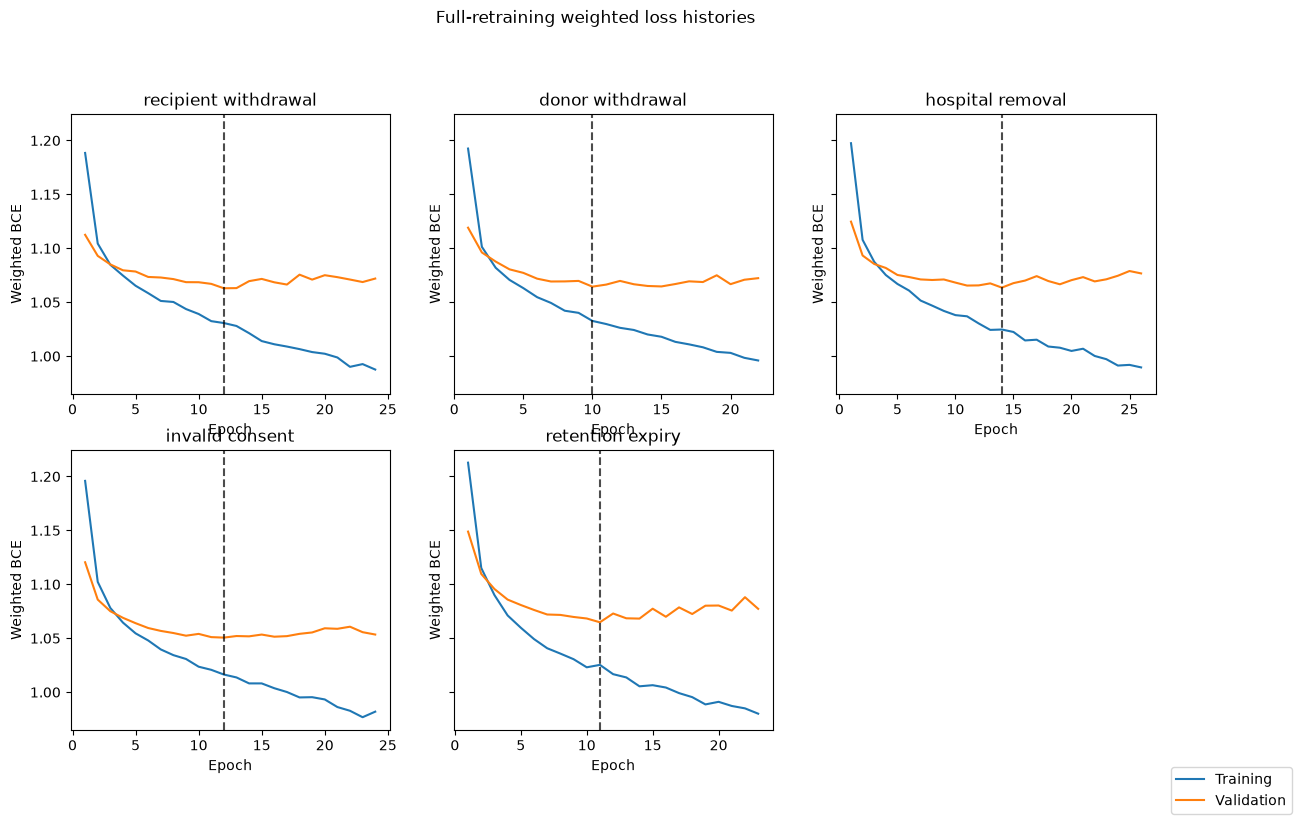

In [72]:
# Keep this training step aligned with the frozen method configuration.
display(training_summary)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False, sharey=True)
for axis, scenario in zip(axes.flat, SCENARIOS):
    frame = training_history.loc[training_history["scenario"].eq(scenario)]
    best_epoch = int(training_summary.loc[training_summary["scenario"].eq(scenario), "best_epoch"].iloc[0])
    axis.plot(frame["epoch"], frame["training_weighted_bce"], label="Training")
    axis.plot(frame["epoch"], frame["validation_weighted_bce"], label="Validation")
    axis.axvline(best_epoch, color="black", linestyle="--", alpha=0.7)
    axis.set_title(scenario.replace("_", " "))
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Weighted BCE")
axes.flat[-1].axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right")
fig.suptitle("Full-retraining weighted loss histories", y=1.01)


In [73]:
fig.tight_layout()
fig.savefig(FIGURE_DIR / "full_retraining_loss_curves.png", dpi=180, bbox_inches="tight")
plt.show()

Runtime and selected epoch are descriptive hardware-dependent results. Small differences are not treated as substantively meaningful without repeated timing evidence.

In [74]:
display(training_summary[['scenario', 'retained_training_rows', 'epochs_executed', 'best_epoch', 'training_seconds']])

,scenario,retained_training_rows,epochs_executed,best_epoch,training_seconds
0,recipient_withdrawal,41598,24,12,3.923029
1,donor_withdrawal,40032,22,10,3.450068
2,hospital_removal,37710,26,14,3.847863
3,invalid_consent,37876,24,12,3.528170
4,retention_expiry,35762,23,11,3.111061


The calculated training summary below reports completion, selected epochs and single-run timings for all five references.

In [75]:
# Keep this training step aligned with the frozen method configuration.
fastest = training_summary.loc[training_summary["training_seconds"].idxmin()]
slowest = training_summary.loc[training_summary["training_seconds"].idxmax()]
display(Markdown(
    f"All five fresh models trained stably and restored a best retained-validation state. Executed epochs "
    f"range from **{training_summary['epochs_executed'].min()} to {training_summary['epochs_executed'].max()}**. "
    f"Observed training time ranges from **{fastest.training_seconds:.2f}s** ({fastest.scenario}) to "
    f"**{slowest.training_seconds:.2f}s** ({slowest.scenario}); these single CPU timings are descriptive."
))

All five fresh models trained stably and restored a best retained-validation state. Executed epochs range from **22 to 26**. Observed training time ranges from **3.11s** (retention_expiry) to **3.92s** (recipient_withdrawal); these single CPU timings are descriptive.

# 10. Evaluate retained utility and forgotten-record behaviour

Each restored model generates probabilities on its scenario-retained test rows. Threshold 0.62 produces classes. Probability metrics use probabilities; evaluation BCE is unweighted.

In [76]:
# Preserve row order so baseline and retrained predictions align exactly.
def predict_probabilities(model, matrix, batch_size=2048):
    model.eval()
    outputs = []
    loader = DataLoader(
        TensorDataset(torch.from_numpy(matrix.astype(np.float32))),
        batch_size=batch_size, shuffle=False, num_workers=0,
    )
    with torch.no_grad():
        for (batch_x,) in loader:
            outputs.append(torch.sigmoid(model(batch_x.to(DEVICE))).cpu().numpy())
    return np.concatenate(outputs)


In [77]:
# Calculate the established evaluation outputs without changing model selection.


def binary_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "n": int(len(y_true)), "positive_count": int(y_true.sum()),
        "prevalence": float(y_true.mean()), "threshold": float(threshold),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "auroc": float(roc_auc_score(y_true, probabilities)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "binary_cross_entropy": float(log_loss(y_true, probabilities, labels=[0, 1])),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "specificity": float(tn / (tn + fp)), "accuracy": float(accuracy_score(y_true, predictions)),
        "positive_prediction_rate": float(predictions.mean()),
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp),
    }

In [78]:
# Keep retained test data out of training and checkpoint selection.
# Evaluate restored models on retained test rows at the frozen threshold.
retrained_probabilities = {}
retrained_metric_rows = []
for scenario in SCENARIOS:
    values = scenario_matrices[scenario]["retained_test"]
    model_probabilities = predict_probabilities(scenario_models[scenario], values["X"])
    probabilities = np.asarray(model_probabilities, dtype=np.float64)
    retrained_probabilities[scenario] = probabilities
    metrics = binary_metrics(values["y"], probabilities, FROZEN_THRESHOLD)
    retrained_metric_rows.append({"scenario": scenario, "model": "full_retraining", **metrics})
retrained_utility = pd.DataFrame(retrained_metric_rows)
display(retrained_utility)


,scenario,model,n,positive_count,prevalence,threshold,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,precision,recall,specificity,accuracy,positive_prediction_rate,true_negative,false_positive,false_negative,true_positive
0,recipient_withdrawal,full_retraining,8898,656,0.073724,0.62,0.177118,0.734572,0.628800,0.234677,0.590813,0.159539,0.443598,0.814001,0.786694,0.204990,6709,1533,365,291
1,donor_withdrawal,full_retraining,8496,628,0.073917,0.62,0.173580,0.731609,0.633887,0.236778,0.599383,0.159016,0.463376,0.804398,0.779190,0.215395,6329,1539,337,291
2,hospital_removal,full_retraining,8124,605,0.074471,0.62,0.176205,0.743964,0.641917,0.249229,0.590414,0.169868,0.467769,0.816066,0.790128,0.205071,6136,1383,322,283
3,invalid_consent,full_retraining,8078,570,0.070562,0.62,0.167787,0.735362,0.637605,0.229071,0.595136,0.150191,0.482456,0.792754,0.770859,0.226665,5952,1556,295,275
4,retention_expiry,full_retraining,7614,554,0.072761,0.62,0.162155,0.741491,0.627631,0.227008,0.585620,0.151045,0.456679,0.798584,0.773706,0.219989,5638,1422,301,253


For each scenario the unchanged baseline uses its original fitted preprocessor, while the retrained model uses its matching retained-data preprocessor. Both are evaluated on exactly the same retained test IDs at threshold 0.62. Positive deltas favour PR-AUC, AUROC, balanced accuracy and F1; lower BCE is better, so a positive BCE delta is worse.

In [79]:
# Compare both models on the same retained test IDs for each scenario.
baseline_metric_rows = []
retained_prediction_frames = []


In [80]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    retained_test = scenario_sets[scenario]["retained_test"]
    baseline_matrix = baseline_preprocessor.transform(
        retained_test[classifier_features]
    ).astype(np.float32)
    baseline_prob = np.asarray(
        predict_probabilities(baseline_model, baseline_matrix), dtype=np.float64
    )
    full_prob = np.asarray(retrained_probabilities[scenario], dtype=np.float64)
    y_true = retained_test[target_column].to_numpy(dtype=np.int64)
    assert len(baseline_prob) == len(full_prob) == len(retained_test)
    saved_baseline = baseline_saved_predictions.set_index("assessment_id").loc[
        retained_test["assessment_id"], "probability"
    ].to_numpy(dtype=np.float64)
    assert np.allclose(baseline_prob, saved_baseline, atol=1e-7, rtol=1e-7)
    baseline_metric_rows.append({
        "scenario": scenario, "model": "baseline",
        **binary_metrics(y_true, baseline_prob, FROZEN_THRESHOLD),
    })
    prediction_frame = retained_test[["assessment_id", "recipient_id"]].copy()
    prediction_frame.insert(0, "scenario", scenario)
    prediction_frame["true_target"] = y_true
    prediction_frame["baseline_probability"] = baseline_prob
    prediction_frame["full_retraining_probability"] = full_prob
    prediction_frame["baseline_prediction"] = (baseline_prob >= FROZEN_THRESHOLD).astype(np.int64)
    prediction_frame["full_retraining_prediction"] = (full_prob >= FROZEN_THRESHOLD).astype(np.int64)
    retained_prediction_frames.append(prediction_frame)


In [81]:

baseline_utility = pd.DataFrame(baseline_metric_rows)
utility_metrics = pd.concat([baseline_utility, retrained_utility], ignore_index=True)
retained_test_predictions = pd.concat(retained_prediction_frames, ignore_index=True)


In [82]:
# Compare utility changes using the same metric definitions as baseline.
comparison_metrics = [
    "pr_auc", "auroc", "balanced_accuracy", "f1", "binary_cross_entropy",
    "precision", "recall", "specificity", "accuracy", "positive_prediction_rate",
]
baseline_wide = baseline_utility.set_index("scenario")[comparison_metrics]
retrained_wide = retrained_utility.set_index("scenario")[comparison_metrics]
utility_deltas = (retrained_wide - baseline_wide).reset_index()
utility_deltas = utility_deltas.rename(columns={
    metric: f"delta_{metric}" for metric in comparison_metrics
})
display(utility_metrics)
display(utility_deltas)

,scenario,model,n,positive_count,prevalence,threshold,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,precision,recall,specificity,accuracy,positive_prediction_rate,true_negative,false_positive,false_negative,true_positive
0,recipient_withdrawal,baseline,8898,656,0.073724,0.62,0.169267,0.731534,0.630478,0.244288,0.574755,0.171605,0.423780,0.837175,0.806698,0.182063,6900,1342,378,278
1,donor_withdrawal,baseline,8496,628,0.073917,0.62,0.168604,0.731754,0.630475,0.244170,0.574600,0.171264,0.425159,0.835791,0.805438,0.183498,6576,1292,361,267
2,hospital_removal,baseline,8124,605,0.074471,0.62,0.173596,0.739196,0.636655,0.252029,0.573226,0.177181,0.436364,0.836946,0.807115,0.183407,6293,1226,341,264
3,invalid_consent,baseline,8078,570,0.070562,0.62,0.163900,0.735045,0.628857,0.237052,0.559673,0.165508,0.417544,0.840170,0.810349,0.178014,6308,1200,332,238
4,retention_expiry,baseline,7614,554,0.072761,0.62,0.167302,0.744495,0.634281,0.252886,0.540615,0.181818,0.415162,0.853399,0.821513,0.166141,6025,1035,324,230
5,recipient_withdrawal,full_retraining,8898,656,0.073724,0.62,0.177118,0.734572,0.628800,0.234677,0.590813,0.159539,0.443598,0.814001,0.786694,0.204990,6709,1533,365,291
6,donor_withdrawal,full_retraining,8496,628,0.073917,0.62,0.173580,0.731609,0.633887,0.236778,0.599383,0.159016,0.463376,0.804398,0.779190,0.215395,6329,1539,337,291
7,hospital_removal,full_retraining,8124,605,0.074471,0.62,0.176205,0.743964,0.641917,0.249229,0.590414,0.169868,0.467769,0.816066,0.790128,0.205071,6136,1383,322,283
8,invalid_consent,full_retraining,8078,570,0.070562,0.62,0.167787,0.735362,0.637605,0.229071,0.595136,0.150191,0.482456,0.792754,0.770859,0.226665,5952,1556,295,275
9,retention_expiry,full_retraining,7614,554,0.072761,0.62,0.162155,0.741491,0.627631,0.227008,0.585620,0.151045,0.456679,0.798584,0.773706,0.219989,5638,1422,301,253


,scenario,delta_pr_auc,delta_auroc,delta_balanced_accuracy,delta_f1,delta_binary_cross_entropy,delta_precision,delta_recall,delta_specificity,delta_accuracy,delta_positive_prediction_rate
0,recipient_withdrawal,0.007851,0.003038,-0.001678,-0.009611,0.016058,-0.012065,0.019817,-0.023174,-0.020004,0.022927
1,donor_withdrawal,0.004975,-0.000145,0.003412,-0.007392,0.024782,-0.012247,0.038217,-0.031393,-0.026248,0.031897
2,hospital_removal,0.002609,0.004769,0.005262,-0.002799,0.017189,-0.007313,0.031405,-0.020880,-0.016987,0.021664
3,invalid_consent,0.003887,0.000317,0.008748,-0.007981,0.035463,-0.015316,0.064912,-0.047416,-0.039490,0.048651
4,retention_expiry,-0.005147,-0.003004,-0.006650,-0.025879,0.045006,-0.030773,0.041516,-0.054816,-0.047807,0.053848


Full retraining never trains on these records, yet may still predict them correctly through generalisation. Changed predictions are not proof of forgetting, and unchanged predictions are not proof of failure.

In [83]:
# Preserve full-retraining probabilities as the behavioural forgetting reference.
# Save behaviour on forgotten training rows for later method comparisons.
EPSILON = 1e-12
forget_reference_frames = []


In [84]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    forget_frame = scenario_sets[scenario]["training_forget"]
    baseline_matrix = baseline_preprocessor.transform(forget_frame[classifier_features]).astype(np.float32)
    baseline_prob = np.asarray(
        predict_probabilities(baseline_model, baseline_matrix), dtype=np.float64
    )
    full_matrix = scenario_matrices[scenario]["training_forget"]["X"]
    full_prob = np.asarray(
        predict_probabilities(scenario_models[scenario], full_matrix), dtype=np.float64
    )
    y_true = forget_frame[target_column].to_numpy(dtype=np.int64)
    baseline_clipped = np.clip(baseline_prob, EPSILON, 1 - EPSILON)
    full_clipped = np.clip(full_prob, EPSILON, 1 - EPSILON)
    baseline_bce = -(y_true * np.log(baseline_clipped) + (1-y_true) * np.log(1-baseline_clipped))
    full_bce = -(y_true * np.log(full_clipped) + (1-y_true) * np.log(1-full_clipped))
    output = forget_frame[["assessment_id", "recipient_id"]].copy()
    output.insert(0, "scenario", scenario)
    output["true_target"] = y_true
    output["baseline_probability"] = baseline_prob
    output["full_retraining_probability"] = full_prob
    output["baseline_prediction"] = (baseline_prob >= FROZEN_THRESHOLD).astype(np.int64)
    output["full_retraining_prediction"] = (full_prob >= FROZEN_THRESHOLD).astype(np.int64)
    output["baseline_per_record_bce"] = baseline_bce
    output["full_retraining_per_record_bce"] = full_bce
    output["absolute_probability_difference"] = np.abs(full_prob - baseline_prob)
    output["prediction_changed"] = output["baseline_prediction"].ne(output["full_retraining_prediction"])
    forget_reference_frames.append(output)


In [85]:
forget_reference_predictions = pd.concat(forget_reference_frames, ignore_index=True)


For binary classification, `p_true` is the probability assigned to the observed class and `p_incorrect` to the other class. The adapted truth ratio is `(p_incorrect + epsilon) / (p_true + epsilon)` with epsilon `1e-12`. No single value proves forgetting; later notebooks compare approximate-method distributions with these references using KS statistics and p-values.

In [86]:
# Truth Ratio compares confidence in the incorrect and true classes.
# Calculate the full-retraining truth-ratio reference for every forgotten row.
truth_ratio_frames = []


In [87]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    frame = forget_reference_predictions.loc[
        forget_reference_predictions["scenario"].eq(scenario)
    ].copy()
    probability = frame["full_retraining_probability"].to_numpy(dtype=np.float64)
    target = frame["true_target"].to_numpy(dtype=np.int64)
    p_true = np.where(target == 1, probability, 1 - probability)
    p_incorrect = np.where(target == 1, 1 - probability, probability)
    truth_ratio = (p_incorrect + EPSILON) / (p_true + EPSILON)
    truth_ratio_frames.append(pd.DataFrame({
        "scenario": scenario,
        "assessment_id": frame["assessment_id"].to_numpy(),
        "recipient_id": frame["recipient_id"].to_numpy(),
        "true_target": target,
        "p_true": p_true,
        "p_incorrect": p_incorrect,
        "full_retraining_truth_ratio": truth_ratio,
        "epsilon": EPSILON,
    }))


In [88]:
truth_ratio_values = pd.concat(truth_ratio_frames, ignore_index=True)


In [89]:
# Summarise reference distributions without imposing a decision threshold.
truth_ratio_summary_rows = []
for scenario, frame in truth_ratio_values.groupby("scenario", sort=False):
    values = frame["full_retraining_truth_ratio"]
    truth_ratio_summary_rows.append({
        "scenario": scenario, "count": len(values),
        "mean": values.mean(), "median": values.median(),
        "q1": values.quantile(0.25), "q3": values.quantile(0.75),
        "interquartile_range": values.quantile(0.75) - values.quantile(0.25),
        "minimum": values.min(), "maximum": values.max(),
    })
truth_ratio_summary = pd.DataFrame(truth_ratio_summary_rows)
display(truth_ratio_summary)

,scenario,count,mean,median,q1,q3,interquartile_range,minimum,maximum
0,recipient_withdrawal,426,0.951461,0.842090,0.237207,1.313340,1.076133,5.452608e-09,6.323519
1,donor_withdrawal,1992,1.065314,0.963850,0.417091,1.516182,1.099091,1.271374e-07,7.135536
2,hospital_removal,4314,1.011090,0.882400,0.308297,1.430740,1.122443,4.613736e-09,10.233602
3,invalid_consent,4148,1.261086,1.043372,0.700872,1.554443,0.853571,1.057704e-04,10.187212
4,retention_expiry,6262,1.442658,1.148926,0.733981,1.808173,1.074192,3.792301e-04,10.828927


This table combines deletion size and structure with retained-test utility, deltas, runtime and forget-set behaviour. Observed associations—especially between the two 10% scenarios—are described cautiously rather than treated as causal effects.

In [90]:
# Describe forgotten-record behaviour without using it for selection.
forget_behaviour = forget_reference_predictions.groupby("scenario", sort=False).agg(
    forget_rows=("assessment_id", "size"),
    mean_absolute_probability_difference=("absolute_probability_difference", "mean"),
    median_absolute_probability_difference=("absolute_probability_difference", "median"),
    prediction_change_rate=("prediction_changed", "mean"),
).reset_index()


In [91]:
# Keep this training step aligned with the frozen method configuration.

scenario_comparison = scenario_definition_summary.merge(
    training_summary[["scenario", "training_seconds", "best_epoch"]], on="scenario"
).merge(
    retrained_utility[["scenario", "pr_auc", "auroc", "balanced_accuracy", "f1", "binary_cross_entropy"]],
    on="scenario"
).merge(
    utility_deltas, on="scenario"
).merge(
    forget_behaviour, on="scenario"
).merge(
    truth_ratio_summary[["scenario", "median", "interquartile_range"]], on="scenario"
)
display(scenario_comparison)

,scenario,rows_affected,full_dataset_percentage,recipients_affected,donors_affected,hospitals_affected,complete_histories_removed,partial_histories_affected,structural_type,training_seconds,...,delta_recall,delta_specificity,delta_accuracy,delta_positive_prediction_rate,forget_rows,mean_absolute_probability_difference,median_absolute_probability_difference,prediction_change_rate,median,interquartile_range
0,recipient_withdrawal,600,0.01,100,100,10,100,0,person-level complete-history,3.923029,...,0.019817,-0.023174,-0.020004,0.022927,426,0.022657,0.014653,0.042254,0.842090,1.076133
1,donor_withdrawal,3000,0.05,500,250,10,500,0,linked-entity complete-history,3.450068,...,0.038217,-0.031393,-0.026248,0.031897,1992,0.023813,0.018157,0.059237,0.963850,1.099091
2,hospital_removal,6000,0.10,1000,982,1,1000,0,provider-cluster complete-history,3.847863,...,0.031405,-0.020880,-0.016987,0.021664,4314,0.025443,0.018644,0.063514,0.882400,1.122443
3,invalid_consent,6000,0.10,3800,3516,10,0,3800,distributed partial-history,3.528170,...,0.064912,-0.047416,-0.039490,0.048651,4148,0.030447,0.024479,0.075217,1.043372,0.853571
4,retention_expiry,9000,0.15,3700,3408,10,0,3700,time-based partial-history,3.111061,...,0.041516,-0.054816,-0.047807,0.053848,6262,0.040061,0.033233,0.099329,1.148926,1.074192


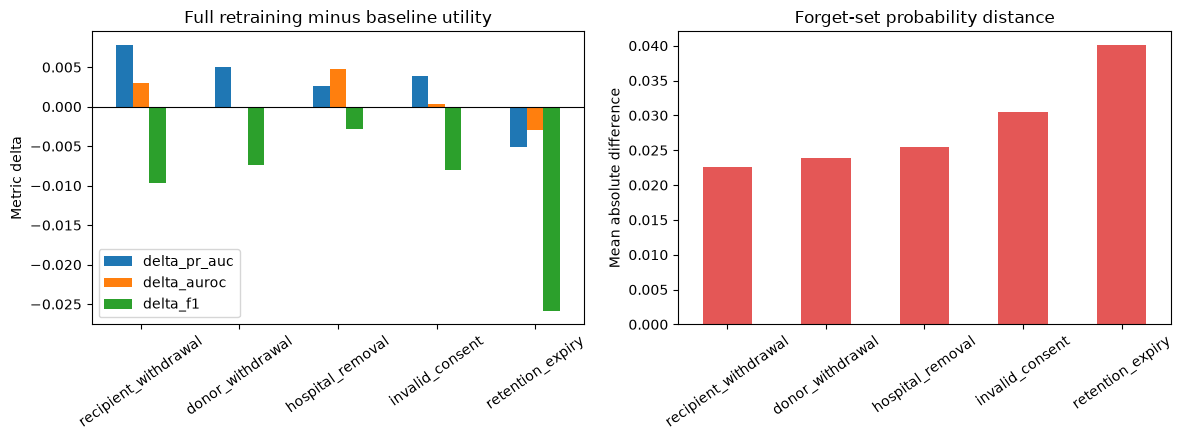

In [92]:
# Calculate the established evaluation outputs without changing model selection.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_frame = utility_deltas.set_index("scenario")
plot_frame[["delta_pr_auc", "delta_auroc", "delta_f1"]].plot.bar(ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Full retraining minus baseline utility", ylabel="Metric delta", xlabel="")
axes[0].tick_params(axis="x", rotation=35)

forget_behaviour.set_index("scenario")[["mean_absolute_probability_difference"]].plot.bar(
    ax=axes[1], legend=False, color="#e45756"
)
axes[1].set(title="Forget-set probability distance", ylabel="Mean absolute difference", xlabel="")
axes[1].tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "full_retraining_comparison.png", dpi=180)
plt.show()

The following calculated finding summarises utility differences and forgotten-record behaviour without treating one run as causal evidence.

In [93]:
# Keep this stage separate so its inputs and checks remain easy to audit.
absolute_pr_change = utility_deltas.set_index("scenario")["delta_pr_auc"].abs()
largest_change = absolute_pr_change.idxmax()
smallest_change = absolute_pr_change.idxmin()
hospital_delta = float(utility_deltas.loc[utility_deltas["scenario"].eq("hospital_removal"), "delta_pr_auc"].iloc[0])
consent_delta = float(utility_deltas.loc[utility_deltas["scenario"].eq("invalid_consent"), "delta_pr_auc"].iloc[0])
display(Markdown(
    f"By absolute retained-test PR-AUC change, **{largest_change}** changed most and "
    f"**{smallest_change}** least. The equal-sized 10% hospital and consent scenarios had PR-AUC deltas "
    f"of **{hospital_delta:+.6f}** and **{consent_delta:+.6f}** respectively. These five observations do not "
    f"show that size or structure caused the differences. Mean forget-set probability distances range from "
    f"**{forget_behaviour['mean_absolute_probability_difference'].min():.6f}** to "
    f"**{forget_behaviour['mean_absolute_probability_difference'].max():.6f}**. Full retraining is the later "
    f"comparison reference because affected training rows were excluded—not proof of absolute erasure."
))

By absolute retained-test PR-AUC change, **recipient_withdrawal** changed most and **hospital_removal** least. The equal-sized 10% hospital and consent scenarios had PR-AUC deltas of **+0.002609** and **+0.003887** respectively. These five observations do not show that size or structure caused the differences. Mean forget-set probability distances range from **0.022657** to **0.040061**. Full retraining is the later comparison reference because affected training rows were excluded—not proof of absolute erasure.

# 11. Save and verify reference artefacts

Each scenario receives three flat, consistently prefixed files: checkpoint, fitted preprocessor and configuration. Configurations record scenario, feature order, input dimension, architecture, parameters, selected epoch, class weight, threshold and seed.

In [94]:
# Save one fresh model and retained-data preprocessor per scenario.
model_artifact_rows = []


In [95]:
# Keep this training step aligned with the frozen method configuration.
for scenario in SCENARIOS:
    training_row = training_summary.set_index("scenario").loc[scenario]
    checkpoint = {
        "model_state_dict": scenario_models[scenario].state_dict(),
        "input_dim": 24, "hidden_dims": [64, 32], "dropout": 0.10,
        "scenario": scenario, "best_epoch": int(training_row["best_epoch"]),
        "threshold": FROZEN_THRESHOLD, "seed": SEED,
    }
    model_path = MODEL_DIR / f"{scenario}_model.pt"
    preprocessor_path = MODEL_DIR / f"{scenario}_preprocessor.joblib"
    configuration_path = MODEL_DIR / f"{scenario}_configuration.json"
    torch.save(checkpoint, model_path)
    joblib.dump(scenario_preprocessors[scenario], preprocessor_path)
    configuration = {
        "scenario": scenario, "classifier_features": classifier_features,
        "processed_feature_order": scenario_matrices[scenario]["feature_order"],
        "processed_input_dimension": 24, "hidden_dims": [64, 32], "dropout": 0.10,
        "parameter_count": 3_713, "best_epoch": int(training_row["best_epoch"]),
        "positive_class_weight": float(training_row["positive_class_weight"]),
        "threshold": FROZEN_THRESHOLD, "seed": SEED,
    }
    configuration_path.write_text(json.dumps(configuration, indent=2) + chr(10), encoding="utf-8")
    model_artifact_rows.append({
        "scenario": scenario, "model": model_path.relative_to(ROOT).as_posix(),
        "preprocessor": preprocessor_path.relative_to(ROOT).as_posix(),
        "configuration": configuration_path.relative_to(ROOT).as_posix(),
    })


In [96]:
model_artifacts = pd.DataFrame(model_artifact_rows)
display(model_artifacts)

,scenario,model,preprocessor,configuration
0,recipient_withdrawal,models/full_retraining/recipient_withdrawal_mo...,models/full_retraining/recipient_withdrawal_pr...,models/full_retraining/recipient_withdrawal_co...
1,donor_withdrawal,models/full_retraining/donor_withdrawal_model.pt,models/full_retraining/donor_withdrawal_prepro...,models/full_retraining/donor_withdrawal_config...
2,hospital_removal,models/full_retraining/hospital_removal_model.pt,models/full_retraining/hospital_removal_prepro...,models/full_retraining/hospital_removal_config...
3,invalid_consent,models/full_retraining/invalid_consent_model.pt,models/full_retraining/invalid_consent_preproc...,models/full_retraining/invalid_consent_configu...
4,retention_expiry,models/full_retraining/retention_expiry_model.pt,models/full_retraining/retention_expiry_prepro...,models/full_retraining/retention_expiry_config...


Combined tables avoid redundant retained-dataset copies. Completion is recorded only after artifact, metric, truth-ratio, model-output, configuration and membership checks pass.

In [97]:
# Keep combined filenames stable because later notebooks load them directly.
scenario_summary_output = scenario_definition_summary.merge(
    scenario_size_validation[[
        "scenario", "training_forget_rows", "training_percentage",
        "retained_training_rows", "deleted_validation_rows",
        "retained_validation_rows", "deleted_test_rows", "retained_test_rows",
    ]],
    on="scenario", validate="one_to_one",
)


In [98]:
# Calculate the established evaluation outputs without changing model selection.
csv_outputs = {
    "scenario_summary.csv": scenario_summary_output,
    "training_history.csv": training_history,
    "training_summary.csv": training_summary,
    "utility_metrics.csv": utility_metrics,
    "utility_deltas.csv": utility_deltas,
    "retained_test_predictions.csv": retained_test_predictions,
    "forget_set_reference_predictions.csv": forget_reference_predictions,
    "truth_ratio_reference_values.csv": truth_ratio_values,
}
for filename, frame in csv_outputs.items():
    frame.to_csv(RESULT_DIR / filename, index=False, float_format="%.17g")

The running summary is deliberately excluded: a completed summary is not required until all verification has passed.

In [99]:
# Retain these checks because downstream notebooks require every listed artifact.
expected_combined_files = [
    MEMBERSHIP_PATH, RESULT_DIR / "scenario_summary.csv",
    RESULT_DIR / "training_history.csv", RESULT_DIR / "training_summary.csv",
    RESULT_DIR / "utility_metrics.csv", RESULT_DIR / "utility_deltas.csv",
    RESULT_DIR / "retained_test_predictions.csv",
    RESULT_DIR / "forget_set_reference_predictions.csv",
    RESULT_DIR / "truth_ratio_reference_values.csv",
    FIGURE_DIR / "full_retraining_loss_curves.png",
    FIGURE_DIR / "full_retraining_comparison.png",
]
expected_model_files = [
    MODEL_DIR / f"{scenario}_{suffix}"
    for scenario in SCENARIOS
    for suffix in ("model.pt", "preprocessor.joblib", "configuration.json")
]


In [100]:
# Fail early if this stage no longer matches the frozen experiment contract.
required_artifact_pass = all(path.is_file() for path in expected_combined_files + expected_model_files)
scenario_completeness_pass = (
    set(utility_metrics["scenario"]) == set(SCENARIOS)
    and utility_metrics.groupby("scenario")["model"].nunique().eq(2).all()
    and len(retained_test_predictions) == sum(len(parts["retained_test"]) for parts in scenario_sets.values())
    and len(forget_reference_predictions) == int(forget_summary["forget_rows"].sum())
    and len(truth_ratio_values) == len(forget_reference_predictions)
)
assert required_artifact_pass and scenario_completeness_pass

Every saved baseline and full-retraining metric is independently recalculated from the saved probability table.

In [101]:
# Recalculate saved metrics from probabilities rather than trusting memory.
saved_predictions = pd.read_csv(RESULT_DIR / "retained_test_predictions.csv")
saved_utility = pd.read_csv(RESULT_DIR / "utility_metrics.csv")
metric_columns = [
    "n", "positive_count", "prevalence", "threshold", "pr_auc", "auroc",
    "balanced_accuracy", "f1", "binary_cross_entropy", "precision", "recall",
    "specificity", "accuracy", "positive_prediction_rate", "true_negative",
    "false_positive", "false_negative", "true_positive",
]
integer_metrics = {"n", "positive_count", "true_negative", "false_positive",
                   "false_negative", "true_positive"}
diagnostic_rows = []


In [102]:
# Calculate the established evaluation outputs without changing model selection.
for scenario in SCENARIOS:
    frame = saved_predictions.loc[saved_predictions["scenario"].eq(scenario)]
    y_true = frame["true_target"].to_numpy(dtype=np.int64)
    for model_name, probability_column in [
        ("baseline", "baseline_probability"),
        ("full_retraining", "full_retraining_probability"),
    ]:
        recalculated = binary_metrics(
            y_true, frame[probability_column].to_numpy(dtype=np.float64), FROZEN_THRESHOLD
        )
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model_name)
        ].iloc[0]
        for metric in metric_columns:
            tolerance = 0.0 if metric in integer_metrics else 1e-8
            difference = abs(float(saved_row[metric]) - float(recalculated[metric]))
            diagnostic_rows.append({"scenario": scenario, "model": model_name, "metric": metric,
                "saved_value": saved_row[metric], "recalculated_value": recalculated[metric],
                "absolute_difference": difference, "required_tolerance": tolerance,
                "pass": difference <= tolerance})


In [103]:
# Fail early if this stage no longer matches the frozen experiment contract.
metric_diagnostic = pd.DataFrame(diagnostic_rows)
metric_diagnostic.to_csv(
    RESULT_DIR / "metric_reproduction_diagnostic.csv", index=False, float_format="%.17g"
)
metric_reproduction_pass = bool(metric_diagnostic["pass"].all())
display(metric_diagnostic.loc[~metric_diagnostic["pass"]])
assert metric_reproduction_pass

,scenario,model,metric,saved_value,recalculated_value,absolute_difference,required_tolerance,pass


The saved truth ratios are reproduced through the canonical float64 path. Notebook 02 creates one full-retraining reference distribution per scenario and defines no two-sample KS result; KS reproduction is therefore recorded as not applicable here and is performed in Notebook 03.

In [104]:
# Reproduce truth ratios through the canonical float64 calculation.
saved_forget = pd.read_csv(RESULT_DIR / "forget_set_reference_predictions.csv")
saved_truth = pd.read_csv(RESULT_DIR / "truth_ratio_reference_values.csv")
merged_reference = saved_truth.merge(
    saved_forget[["scenario", "assessment_id", "full_retraining_probability"]],
    on=["scenario", "assessment_id"], validate="one_to_one",
)
saved_epsilons = merged_reference["epsilon"].drop_duplicates().to_numpy(dtype=np.float64)
epsilon_pass = bool(
    len(saved_epsilons) == 1
    and abs(float(saved_epsilons[0]) - EPSILON) <= np.spacing(np.float64(EPSILON))
)
probability = merged_reference["full_retraining_probability"].to_numpy(dtype=np.float64)
target = merged_reference["true_target"].to_numpy(dtype=np.int64)
recalculated_true = np.where(target == 1, probability, 1 - probability)
recalculated_incorrect = np.where(target == 1, 1 - probability, probability)


In [105]:
# Save reproducibility artefacts only after the corresponding checks have passed.
recalculated_ratio = (recalculated_incorrect + EPSILON) / (recalculated_true + EPSILON)
stored_ratio = merged_reference["full_retraining_truth_ratio"].to_numpy(dtype=np.float64)
ratio_difference = np.abs(stored_ratio - recalculated_ratio)
ratio_reproduction_pass = bool(np.allclose(stored_ratio, recalculated_ratio, atol=1e-8, rtol=0))
ratio_diagnostic = pd.DataFrame([{
    "rows": len(merged_reference),
    "unique_keys": not merged_reference.duplicated(["scenario", "assessment_id"]).any(),
    "epsilon": EPSILON, "epsilon_pass": epsilon_pass,
    "verification_mode": "canonical_float64",
    "maximum_absolute_difference": float(ratio_difference.max()),
    "required_tolerance": 1e-8, "pass": ratio_reproduction_pass and epsilon_pass,
}])
ratio_diagnostic.to_csv(
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv", index=False, float_format="%.17g"
)


In [106]:
# Fail early if this stage no longer matches the frozen experiment contract.
ks_reproduction = pd.DataFrame([{
    "status": "NOT_APPLICABLE", "pass": True,
    "reason": "Notebook 02 defines reference distributions but no two-sample KS result",
}])
display(ratio_diagnostic)
display(ks_reproduction)
assert bool(ratio_diagnostic["pass"].all()) and bool(ks_reproduction["pass"].all())

,rows,unique_keys,epsilon,epsilon_pass,verification_mode,maximum_absolute_difference,required_tolerance,pass
0,17142,True,1.000000e-12,True,canonical_float64,2.842171e-14,1.000000e-08,True


,status,pass,reason
0,NOT_APPLICABLE,True,Notebook 02 defines reference distributions bu...


Each independently reloaded model and preprocessor must reproduce both its retained-test and training-forget probabilities.

In [107]:
# Reload each model and preprocessor and reproduce both prediction sets.
reload_rows = []


In [108]:
# Load frozen inputs so this stage reuses rather than regenerates earlier evidence.
for scenario in SCENARIOS:
    checkpoint = load_checkpoint(MODEL_DIR / f"{scenario}_model.pt")
    preprocessor = joblib.load(MODEL_DIR / f"{scenario}_preprocessor.joblib")
    configuration = json.loads(
        (MODEL_DIR / f"{scenario}_configuration.json").read_text(encoding="utf-8")
    )
    reloaded_model = BaselineMLP(
        checkpoint["input_dim"], tuple(checkpoint["hidden_dims"]), checkpoint["dropout"]
    )
    reloaded_model.load_state_dict(checkpoint["model_state_dict"])
    retained_frame = scenario_sets[scenario]["retained_test"]
    forget_frame = scenario_sets[scenario]["training_forget"]
    retained_matrix = preprocessor.transform(retained_frame[classifier_features]).astype(np.float32)
    forget_matrix = preprocessor.transform(forget_frame[classifier_features]).astype(np.float32)
    retained_reproduced = predict_probabilities(reloaded_model, retained_matrix).astype(np.float64)
    forget_reproduced = predict_probabilities(reloaded_model, forget_matrix).astype(np.float64)
    retained_saved = saved_predictions.loc[
        saved_predictions["scenario"].eq(scenario), "full_retraining_probability"
    ].to_numpy(dtype=np.float64)
    forget_saved = saved_forget.loc[
        saved_forget["scenario"].eq(scenario), "full_retraining_probability"
    ].to_numpy(dtype=np.float64)
    retained_difference = float(np.max(np.abs(retained_reproduced - retained_saved)))
    forget_difference = float(np.max(np.abs(forget_reproduced - forget_saved)))
    metadata_pass = (
        checkpoint["scenario"] == configuration["scenario"] == scenario
        and checkpoint["threshold"] == configuration["threshold"] == FROZEN_THRESHOLD
        and [checkpoint["input_dim"], *checkpoint["hidden_dims"], 1] == [24, 64, 32, 1]
        and configuration["classifier_features"] == classifier_features
        and configuration["processed_feature_order"] == preprocessor.get_feature_names_out().tolist()
        and sum(parameter.numel() for parameter in reloaded_model.parameters()) == 3_713
    )
    reload_rows.append({"scenario": scenario, "retained_test_max_abs_difference": retained_difference,
        "training_forget_max_abs_difference": forget_difference, "metadata_pass": metadata_pass,
        "retained_test_probability_pass": bool(np.allclose(retained_saved, retained_reproduced, atol=1e-8, rtol=1e-8)),
        "training_forget_probability_pass": bool(np.allclose(forget_saved, forget_reproduced, atol=1e-8, rtol=1e-8))})


In [109]:
# Fail early if this stage no longer matches the frozen experiment contract.
model_reload_verification = pd.DataFrame(reload_rows)
model_reload_verification.to_csv(
    RESULT_DIR / "model_reload_verification.csv", index=False, float_format="%.17g"
)
model_reload_pass = bool(model_reload_verification.drop(columns="scenario").filter(like="pass").to_numpy().all())
display(model_reload_verification)
assert model_reload_pass

,scenario,retained_test_max_abs_difference,training_forget_max_abs_difference,metadata_pass,retained_test_probability_pass,training_forget_probability_pass
0,recipient_withdrawal,1.110223e-16,1.110223e-16,True,True,True
1,donor_withdrawal,1.110223e-16,1.110223e-16,True,True,True
2,hospital_removal,1.110223e-16,1.110223e-16,True,True,True
3,invalid_consent,2.220446e-16,1.110223e-16,True,True,True
4,retention_expiry,1.110223e-16,2.220446e-16,True,True,True


Completion requires every hard verification and the frozen membership counts.

In [110]:
# Require frozen membership, architecture, threshold and numerical checks to pass.
expected_forget_counts = {
    "recipient_withdrawal": 426, "donor_withdrawal": 1_992,
    "hospital_removal": 4_314, "invalid_consent": 4_148,
    "retention_expiry": 6_262,
}
membership_counts = (
    deletion_membership.loc[
        deletion_membership["membership_type"].eq("training_forget")
    ]
    .groupby("scenario")
    .size()
    .to_dict()
)


In [111]:
# Fail early if this stage no longer matches the frozen experiment contract.
acceptance = pd.DataFrame([
    {"requirement": "Required artifacts", "pass": required_artifact_pass},
    {"requirement": "Saved metrics reproduce", "pass": metric_reproduction_pass},
    {"requirement": "Truth ratios reproduce", "pass": bool(ratio_diagnostic["pass"].all())},
    {"requirement": "KS check appropriately resolved", "pass": bool(ks_reproduction["pass"].all())},
    {"requirement": "Models, preprocessors, configurations and probabilities reproduce", "pass": model_reload_pass},
    {"requirement": "Scenario outputs are complete", "pass": scenario_completeness_pass},
    {"requirement": "Frozen training-forget membership counts", "pass": membership_counts == expected_forget_counts},
    {"requirement": "No direct identifier classifier inputs", "pass": (identity_direct_fields | {'assessment_id', 'recipient_id', 'donor_id', 'hospital_id'}).isdisjoint(classifier_features)},
    {"requirement": "Frozen threshold and architecture", "pass": FROZEN_THRESHOLD == 0.62 and baseline_config['input_dim_processed'] == 24 and tuple(baseline_config['hidden_dims']) == (64, 32)},
])
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance.drop(columns="pass"))
assert bool(acceptance["pass"].all())

,requirement,status
0,Required artifacts,PASS
1,Saved metrics reproduce,PASS
2,Truth ratios reproduce,PASS
3,KS check appropriately resolved,PASS
4,"Models, preprocessors, configurations and prob...",PASS
5,Scenario outputs are complete,PASS
6,Frozen training-forget membership counts,PASS
7,No direct identifier classifier inputs,PASS
8,Frozen threshold and architecture,PASS


Only the fully verified execution can replace the initial running status with completed.

In [112]:
# Mark the run completed only after every hard check succeeds.
run_summary = {
    "status": "completed", "task": "deletion scenarios and full retraining",
    "seed": SEED, "threshold": FROZEN_THRESHOLD,
    "scenarios": SCENARIOS, "scenario_count": len(SCENARIOS),
    "complete_deletion_rows": dict(zip(
        scenario_definition_summary["scenario"], scenario_definition_summary["rows_affected"]
    )),
    "training_forget_rows": dict(zip(forget_summary["scenario"], forget_summary["forget_rows"])),
    "retained_training_rows": {
        scenario: len(parts["retained_train"]) for scenario, parts in scenario_sets.items()
    },
    "training_seconds": dict(zip(training_summary["scenario"], training_summary["training_seconds"])),
    "all_verification_checks_pass": bool(acceptance["pass"].all()),
    "model_probabilities_reproduced": model_reload_pass,
    "network_requests": 0,
}


In [113]:
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps(run_summary, indent=2) + "\n", encoding="utf-8"
)

1199

The final statement below is produced only after every required artifact and numerical reproduction check passes.

In [114]:
# Visualise established results without using the figure to tune the experiment.
display(Markdown(
    "Later notebooks can reconstruct deletion sets from `processed_data/deletion_scenario_membership.csv`; "
    "load scenario-prefixed checkpoints and preprocessors from `models/full_retraining/`; and read utility, "
    "forget-set probability and truth-ratio references from `results/full_retraining/`. All five lightweight "
    "model/preprocessor/configuration load checks passed."
))

Later notebooks can reconstruct deletion sets from `processed_data/deletion_scenario_membership.csv`; load scenario-prefixed checkpoints and preprocessors from `models/full_retraining/`; and read utility, forget-set probability and truth-ratio references from `results/full_retraining/`. All five lightweight model/preprocessor/configuration load checks passed.

# 12. Findings and limitations

The executed summary below inserts the verified scenario counts, model completions, utility ranges, runtime and forget-reference behaviour directly from calculated tables.

In [115]:
# Keep this stage separate so its inputs and checks remain easy to audit.
display(Markdown(
    f"All **{len(SCENARIOS)}** frozen scenarios passed structural validation and full retraining. Complete "
    f"deletion scopes were {scenario_definition_summary['rows_affected'].tolist()}, while training forget "
    f"sets were {forget_summary['forget_rows'].tolist()}. Retained-test PR-AUC ranged from "
    f"**{retrained_utility['pr_auc'].min():.6f}** to **{retrained_utility['pr_auc'].max():.6f}** and AUROC "
    f"from **{retrained_utility['auroc'].min():.6f}** to **{retrained_utility['auroc'].max():.6f}**. Total "
    f"training time was **{training_summary['training_seconds'].sum():.2f}s**. The two 10% scenarios produced "
    f"different observed deltas, but one pair cannot establish a structural effect. Forget-set probability "
    f"and truth-ratio outputs are saved as full-retraining references, not claims of absolute erasure."
))

All **5** frozen scenarios passed structural validation and full retraining. Complete deletion scopes were [600, 3000, 6000, 6000, 9000], while training forget sets were [426, 1992, 4314, 4148, 6262]. Retained-test PR-AUC ranged from **0.162155** to **0.177118** and AUROC from **0.731609** to **0.743964**. Total training time was **17.86s**. The two 10% scenarios produced different observed deltas, but one pair cannot establish a structural effect. Forget-set probability and truth-ratio outputs are saved as full-retraining references, not claims of absolute erasure.

All five synthetic deletion scenarios were retrained from fresh weights after their forgotten training rows were removed. Retained-test utility stayed broadly similar to the baseline, but differences between scenarios cannot be attributed to deletion size or structure from one controlled run. Prediction changes and truth ratios describe reference behaviour; neither proves erasure by itself.

The study uses generated data, one permanent split, one seed, one small MLP and a fixed threshold of 0.62. Runtime is hardware-dependent and no result establishes clinical effectiveness. Notebook 02 passes the five forget sets, retained-data definitions, fresh models, scenario preprocessors, utility results, truth-ratio distributions and runtime references to the later approximate-unlearning notebooks.

# Results

## 1. Utility by Deletion Scenario

| Scenario | Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | Baseline | 0.1693 | 0.6305 | 0.5748 | 0.2443 | 0.7315 | 0.3394 |
| Recipient Withdrawal | Full Retraining | 0.1771 | 0.6288 | 0.5908 | 0.2347 | 0.7346 | 0.3410 |
| Donor Withdrawal | Baseline | 0.1686 | 0.6305 | 0.5746 | 0.2442 | 0.7318 | 0.3389 |
| Donor Withdrawal | Full Retraining | 0.1736 | 0.6339 | 0.5994 | 0.2368 | 0.7316 | 0.3390 |
| Hospital Removal | Baseline | 0.1736 | 0.6367 | 0.5732 | 0.2520 | 0.7392 | 0.3466 |
| Hospital Removal | Full Retraining | 0.1762 | 0.6419 | 0.5904 | 0.2492 | 0.7440 | 0.3474 |
| Invalid Consent | Baseline | 0.1639 | 0.6289 | 0.5597 | 0.2371 | 0.7350 | 0.3329 |
| Invalid Consent | Full Retraining | 0.1678 | 0.6376 | 0.5951 | 0.2291 | 0.7354 | 0.3319 |
| Retention Expiry | Baseline | 0.1673 | 0.6343 | 0.5406 | 0.2529 | 0.7445 | 0.3432 |
| Retention Expiry | Full Retraining | 0.1622 | 0.6276 | 0.5856 | 0.2270 | 0.7415 | 0.3266 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Forget-Set Reference Behaviour

| Scenario | Training Forget Rows | Baseline Mean Truth Ratio | Full Retraining Mean Truth Ratio | Change |
| --- | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 426 | 0.8848 | 0.9515 | 0.0666 |
| Donor Withdrawal | 1,992 | 0.9799 | 1.0653 | 0.0854 |
| Hospital Removal | 4,314 | 0.9355 | 1.0111 | 0.0756 |
| Invalid Consent | 4,148 | 1.1480 | 1.2611 | 0.1131 |
| Retention Expiry | 6,262 | 1.2783 | 1.4427 | 0.1644 |

This notebook establishes Full Retraining as the scenario-specific forgetting reference; it does not use Full Retraining versus itself as a headline KS comparison.

## 3. Full-Retraining Efficiency

| Scenario | Full Retraining Runtime (s) |
| --- | ---: |
| Recipient Withdrawal | 3.893 |
| Donor Withdrawal | 3.402 |
| Hospital Removal | 3.839 |
| Invalid Consent | 3.453 |
| Retention Expiry | 3.201 |

## 4. Average Across All Five Scenarios

| Model | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 0.1685 | 0.6321 | 0.5646 | 0.2461 | 0.7364 | 0.3402 |
| Full Retraining | 0.1714 | 0.6340 | 0.5923 | 0.2354 | 0.7374 | 0.3371 |

| Efficiency Summary | Mean |
| --- | ---: |
| Full Retraining Runtime (s) | 3.558 |

## Key Findings

- Every scenario has its own retained-test Baseline and Full Retraining evaluation.
- Mean Full Retraining runtime was **3.558 seconds**.
- Full Retraining supplies the within-scenario reference used by later approximate-unlearning notebooks.
